Hi everybody and welcome back. This is lesson 10 of “Practical Deep Learning for Coders”.  It's the second lesson in Part 2, which is where we're going from “Deep Learning Foundations to  Stable Diffusion”. So before we dive back into our notebook, I think, first of all,  let's take a look at some of the interesting work that students in the course have done  over the last week. I'm just going to show a small sample of what's on the forum so  check out the “Share your work here” thread on the forum for many, many more examples. So @puru did some, something interesting, which is to create a bunch of images, of doing a linear  interpolation —I mean, detail is actually spherical linear interpolation but it doesn't  matter—. Doing a linear interpolation between two different latent, you know, noisy, you know,  latent noise starting points for an otter picture and then showed all the intermediate results.  That came out pretty nice and then did something similar starting with an old car prompt and going  to a modern Ferrari prompt —I can't remember exactly what the prompts were— but you can  see how, as it kind of goes through that latent space, it actually is changing the image that's  coming out, I think that's really cool. And then I love the way @namrata took that and took it to  another level in a way which is starting with a dinosaur and turning into a bird and this is  a very cool intermediate picture of one of the steps along the way: the dino-bird . I love it.  Dino-chick, fantastic. So much creativity on the forum, so I loved this, John Richmond took  his daughter's dog and turned it gradually into a unicorn and I thought this one along the way  actually came out very, very nicely. I think this is adorable and I suspect that John has won the  dad of the year or dad of the week, maybe, award this week for this fantastic project. And Maureen did something very interesting, which is, she took Johno's parrot image from his lesson  and tried bringing it across to various different painters styles  and so her question was: “anyone want to guess the artists in the prompts?”.  So I'm just gonna let you pause it before I move on, if you want to try to guess…  And there they are, most of them are pretty obvious, I guess, I think it's so funny that  Frida Kahlo appears in all of her paintings so the parrot actually turned into Frida Kahlo —all  right, not all of her paintings but all of her famous ones— so the very idea of a Frida Kahlo  painting without her and it is so unheard of that the parrot turned into Frida Kahlo. And  I like this Jackson Pollock, it's still got the parrot going on there. So that's, that's a really  lovely one Maureen, thank you. And this is a good reminder to make sure that you check out the,  the other two lesson videos so she was working with Johno's Stable Diffusion  lessons, so be sure to check that out if you haven't yet, it is available on the course webpage  and on the forums and has lots of cool stuff that you can work with, including this parrot. And then the other one to remind you about is the video that Wasim and Tanishq did on the math  of diffusion and I do want to read out what Alex said about this because I'm sure a number of you  feel the same way: “My first reaction on seeing something with the title ‘the math of diffusion’  was to assume that ‘oh, that's just something for all the smart people who have PhDs in maths  on the course, and it'll probably be completely incomprehensible’, but of course it's not that  at all!”. So be sure to check this out even if you don't think of yourself as a math person, I think  it's, you know, some nice background that you may find useful —it's certainly not necessary— but you  might, yeah, I think it's kind of useful to start to dig in some, to some of the math at this point. One particularly interesting project that's been happening during the week is from Jason Antic, who  is a bit of a legend around here, many of you remember him as being the guy that  created DeOldify. And actually worked closely with us on our research which,  together, turned into NoGAN and Decrapify and other things, created lots of papers.  And Jason, yeah, Jason has kindly joined our middle research team  working on the stuff for these lessons and for developing a, kind of, a fastai approach  to Stable Diffusion and he took the idea that I prompted last week, which is maybe we should be  using classic optimizers, rather than differential equation solvers, and he actually made it work  incredibly well already within a week. These faces were generated on a single GPU, in a few hours,  from scratch by using classic, classic Deep Learning optimizers, which is like an unheard  of speed to get this quality of image and we think that this research direction is looking extremely,  extremely promising. So really great news there and thank you Jason for this fantastic progress. Yeah, so maybe we'll do a quick reminder of what we looked at last week.  So last week I used a bit of a mega, Onenote, hand-drawn thing. I thought this week I might just  turn it into some slides that we can use. So the basic idea, if you remember, is that we started  with… if we're doing handwritten digits, for example, we'd start with a number, a number seven,  this would be one of the ones with a stroke through it, that some countries use.  And then we add to it some noise, and the seven plus the noise together would equal this  noisy seven. And so what we then do is we present this noisy seven, as an input, to a U-Net  and we have it try to predict which which pixels are noise, basically, or predict the noise.  And so the U-Net tries to predict the noise from the from the number,  it then compares its prediction to the actual noise. And it's going to then get a loss, which  it can use to update the weights in the U-Net and that's basically how Stable Diffusion the main  bit, if you like, the U-Net, is created. To make it kind of easier for the U-Net we can also pass  in an embedding of the actual digit, the actual number “7”, so for example one-hot encoded vector,  which goes through an embedding layer, and the nice thing about that, to remind you, is that  if we do this then we also have the benefit that then later on we can actually generate specific  digits by saying: I want a number seven or I want number five and it knows what they look like. I've skipped over here the VAE/latents piece which we talked about last week. And to remind  you that's just a computational shortcut, it makes it, it makes it faster and so we don't  need to include that in this picture because it's just a, yeah, it's just a computational  shortcut that we can pre-process things into that latent space with the VAE first, if we wish.  So that's what the U-Net does. Now, then, to remind you, you know, we want to handle  things that are more interesting than just the number seven, we want to, actually,  handle things where we can say for example: “a graceful swan” or “a scene from Hitchcock”  and the way we do that is we turn these sentences into embeddings as well, and we turn them into  embeddings by trying to create embeddings of these sentences, which are as similar as possible  to embeddings of the photos or images that they are connected with, and to remind you the way we  did that or the way that was done, originally, as part of this thing called CLIP, was to basically  download from the internet lots of examples, of lots of images, find their ALT tags and then  for each one we then have their image and its ALT tag so here's the graceful swan and it's ALT tag,  and then we build two models: an image encoder, that turns each image into some feature vector  and then we have a text encoder, that turns each piece of text into a bunch of features,  and then we create a loss function that says that the features for a graceful swan, the text, should  be as close as possible to the features for the picture of a graceful swan, and specifically we take the dot product. And then we add up all the green ones, because these are the ones that we  want to match, and we subtract all the red ones, because those are ones we don't want to match:  those are where the text doesn't match the image. And so that's the Contrastive Loss  which gives us the CL in CLIP. So that's a review of some stuff we did last week and so with this  then we can, we now have a text encoder which we can now say: “a graceful swan” and it will spit  out some embeddings and those are the embeddings that we can feed into our U-Net during training. And so then, we don't haven't been doing any of that training ourselves except for  some fine tuning because it takes a very long time on a lot of computers. But instead we take  pre-trained models and do inference, and the way we do inference is we put in an example of  the thing that we want, that we have an embedding for, so let's say, we're doing handwritten digits,  and we put in some random noise into the U-Net and then it spits out a prediction of which  bits of noise you could remove to leave behind a picture of the number three. Initially it's going  to do quite a bad job of that, so we subtract just a little bit of that noise from the image  to make it a little bit less noisy, and we do it again, and we do it a bunch of times.  So here's what that looks like, creating a —I think somebody here did “a smiling picture of  Jeremy Howard” or something, if I remember correctly— and if we print out the noise at,  kind of, step 0, and at step 6, and at step 12, you can see this first signs of a face starting to  appear. Definitely a face appearing here: 18, 24. By step 30 it's looking much more like a face. By  42 it's getting there, it's just got a few little blemishes to fix up, and here we are. I think I've  slightly messed up my indexes here because it should finish at 60, not 54, but such is life.  It's a rather rosy red lips too —I would have to say—. So remember, in the early days this took a thousand steps and now there are some  shortcuts to make it take 60 steps. And this is what the process looks like and the reason  this doesn't look like normal noise is because now we are actually doing the VAE latents thing  and so, noisy latents don't look like gaussian noise, they look like, well,  they look like this, this is what happens when you decode those noisy latents. Now, you might remember, last week I complained that things are moving too quickly and there was a  couple of papers that had come out the day before and made everything entirely out of date so,  Johno and I and the team have actually now had time to read, read those papers and I thought  now would be a good time to start going through some papers for the first time. So the…  what we're actually going to do is show how these papers have taken the requirement number, required  number of steps to go through this process down from 60 steps to 4 steps, which is pretty amazing. So let's talk about that and the paper is, specifically  is this one “Progressive Distillation for Fast Sampling of Diffusion Models”.  So it's only been a week so I haven't had much of a chance to try to explain this before so  apologies in advance if this is awkward but hopefully it's going to make some sense.  What we're going to start with is, so we're going to start with this process  which is gradually denoising images —and actually I wonder if we can copy it.  Okay, so, how are we going to get this down from 60 steps to 4 steps? The basic idea  is that we're going to do a process. We're going to do a process called “Distillation”  —which I have no idea how to spell but hopefully that's close enough that you get the idea—.  Distillation is a process which is pretty common in Deep Learning and the basic idea of  distillation is that you take something called a Teacher Network, which is some Neural Network that  already knows how to do something, but it might be slow and big. And the Teacher Network is then used  by a Student Network which tries to learn how to do the same thing but faster or with less memory.  And in this case we want ours to be faster. We want to do less steps. And the way we  can do this conceptually, it's actually, in my opinion, reasonably straightforward. We have,  like, when I look at this, and I think like: “wow, you know, Neural Nets are really amazing”.  So, given Neural Nets are really amazing, why is it taking, like, 18 steps to go from there  to there. Like, that seems like something that you should be able to do in one step.  The fact that it's taking 18 steps —and originally, of course, that was hundreds and  hundreds of steps— is because it's kind of that's… that’s just a kind of a side effect of the, of the  math of how this thing was originally developed, you know, this idea of this diffusion process. But the idea in this paper is something that actually we've —I think I might have  even have mentioned in the last lesson, it's something we were thinking of doing ourselves  before this paper beat us to it—. Which is to say, well, what if we train a new model  where the model takes as input this image, right? And puts it through some other U-Net… U-Net  B, okay? And then that spits out some result.  And what we do is we take that result and we compare it to  this image —the thing we actually want—. Because the nice thing is now,  which we've never really had before is, we have, for each intermediate output, like,  the desired goal where we're trying to get to. And so we could compare those two, just using,  you know, whatever, Mean Squared Error. Keep on forgetting to change my pen, Mean Squared Error.  And so then, if we keep doing this for lots and lots of images and lots of lots of pairs  in exactly this way, this U-Net is going to hopefully learn to take these incomplete images  and turn them into complete images. And that is exactly what this paper does. It just says,  okay, now that we've got all these examples of showing what step 36 should turn into at step 54,  let's just feed those examples into a model.  And that works. And you'd kind of expect it to work because you can see that, like a human  would be able to look at this, and if there are competent artists, they could turn that into a,  you know, a well-finished product, so you would expect that a computer could as well. There are some little tweaks around how it makes this work which I'll briefly describe  because we need to be able to go from, kind of, step 1 through to step 10, through to step 20 and  so forth. And so, the the way that it does this it's actually quite clever, what they do is they  initially, so they take their teacher model, so remember the teacher model is one that has already  been trained. Okay so the teacher model already is a complete Stable Diffusion model that's finished:  we take that as a given, and we put in our image —well actually it's noise— we put in our noise,  right? And we put it through two time steps,  okay? And then we train our U-Net B —or whatever you want to call it— to try to go directly from  the noise to time step number 2. And that's pretty easy for it to do. And so then what they  do is they take this —okay, and so this thing here, remember, is called the student model—.  They then say, okay, let's now take that student model  and treat that as the new teacher. So they now take their noise and they run  it through the student model twice, once and twice, and they get out something at the end.  And so then, they try to create a new student —which is a copy of the previous  student— and it learns to go directly from the noise to two goes of the student model,  and you won't be surprised to hear they now take that new student model and use that to go two goes  and then they learn, they use that, then they copy that to become the next student model. And  so they're doing it again and again and again and each time they're basically doubling the amount of  work. So it goes one to two, effectively it's then going two to four, and then four to eight. And  that's basically what they're what they're doing, and they're doing it for multiple different time  steps. So the single student model is learning to both do these initial steps: try to jump  multiple steps at a time, and it's also letting to do these later steps: multiple steps at a time.  And that's it, believe it or not. So this is this neat paper that came out last week  and that's how it works. Now, I mentioned that there was actually two papers.  The second one is called “On Distillation of Guided Diffusion Models”. And  the trick now is, —this second paper, these came out at basically the same time, if I remember  correctly, even though they're building each other from the same teams— is that they say: okay,  this is all very well but we don't just want to create random pictures, we want to be able to  do guidance, right? And you might remember —I hope you remember from  last week— that we used something called Classifier Free Guided Diffusion Models  which, because I'm lazy, we will just use an acronym: Classifier Free Guided  Diffusion Models (CFGDM). And this one, you may recall, we take, let's say we want a cute puppy,  we put in the prompt “cute puppy” into our CLIP text encoder and it spits out an embedding.  And we put that, —let's ignore the VAE latents business— we put that into our U-Net,  but we also put the empty prompt into our CLIP text encoder;  we concatenate these things two together  so that then out the other side we get back two things: we get back the image of the cute puppy  and we get back the image of some arbitrary thing —it could be anything—. And then we,  effectively, do something very much like taking the weighted average of these two things together,  combine them. And then we use that for the next stage of our diffusion process.  Now, what this paper does is it says: this is all pretty awkward, we end up having to train  two images instead of one, and, for different types of levels of guided diffusion, we have to,  like, do it multiple different times, it's all pretty annoying, how do we skip it? And,  based on the description of how we did it before, you may be able to guess. What we do is we do  exactly the same student-teacher distillation we did before, but this time we pass in in addition  the guidance. And so, again, we've got the entire Stable Diffusion model, the  teacher model, available for us, and we are doing actual CFGD (Classifier Free Guided  Diffusion) to create our guided diffusion cute puppy pictures and we're doing it for a range  of different guidance scales —so you might be doing 2 and 7.5 and 12 and whatever, right?— and  those now are becoming inputs to our student model. So the student model now has additional  inputs, it's getting the noise, as always, it's getting the caption or the prompt, —I  guess I should say— as always, but it's now also getting the guidance scale. And so, it's learning  to find out how all of these things are handled by the teacher model —like what does it do?—  after a few steps, each time. So it's exactly the same thing  as before but now it's learning to use the Classifier Free Guided Diffusion as well. Okay so, that's got quite a lot going on there and, if it's a bit confusing, that's okay,  it is a bit confusing and what I would recommend is you check out the extra information  from Johno who has a whole video on this. And one of the cool things, actually, about this video is  it's actually a paper walkthrough. And so, part of this course is, hopefully, we're going to  start reading papers together. Reading papers is extremely intimidating and overwhelming for  all of us, all of the time, —at least for me it never gets any better—. There's a lot of math  and by watching somebody like Johno, who's an expert at this stuff, read through a paper,  you'll kind of get a sense of how he is skipping over lots of the math,  right?, to focus on, in this case, the really important thing which is the actual algorithm.  And when you actually look at the algorithm you start to realize: it's basically all stuff, nearly  all stuff, maybe all stuff that you did in primary school or secondary school: so we've got division.  Okay, sampling from a normal distribution —so high school— subtraction, division,  division, multiplication, right? Oh, okay, we've got a log there, but basically, you know,  there's not too much going on and then when you look at the code you'll find it's, you know, once  you turn this into code, of course, it becomes even more understandable if you're somebody who's  more familiar with code, like me. So yeah, definitely check out Johno's video on this. So, another paper came out about three hours ago and I just have to show you it to you because  I think it's amazing and so, this is definitely the first video about this paper because it yeah,  only came out a few hours ago. But check this out, this is a paper called “Imagic”.  And with this algorithm you can pass in an input image —this is just a, you know,  a photo you've taken or downloaded off the internet— and then you pass in some text saying:  “a bird spreading wings”. And what it's going to try to do is: it's going to try to take this exact  bird, in this exact pose and leave everything as similar as possible, but adjust it just enough  so that the prompt is now matched. So here we take this, this little guy here, and we say:  oh, this is actually one, we want this to be a person giving the thumbs up and this is what  it produces. And you can see everything else is very, very similar to the previous picture.  So this dog is not sitting but if we put in the prompt “a sitting dog”,  it turns it into a sitting dog, leaving everything else as similar as possible.  So here's an example of a waterfall and then you say it's “a children's drawing of a waterfall” and  now it's become a children's drawing. So, lots of people in the YouTube chat going: oh my God,  this is amazing, which it absolutely is and that's why we're going to show you how it works. One of the really amazing things is you're going to realize that you understand how it  works already. Just to show you some more examples, here's the dog image,  here's the sitting dog, the jumping dog playing with a toy, jumping dog holding a frisbee.  Okay, and here's this guy again, giving the thumbs up, crossed arms, integrating pose to  namaste hands, holding a cup. So that's pretty amazing so, I had to show you how this works.  And I'm not going to go into too much detail but I think we can get the idea, actually, pretty well. So what we do is, again, we take, we start with a fully pre-trained, ready to go  generative model like a Stable Diffusion model. And, this is what this is talking about here:  pre-trained Diffusion model, in the paper they actually use a model called Imagen but none of  the details, as far as I can see, in any way, depend on what the model is. It should work just  fine for Stable Diffusion. And we take “a photo of a bird spreading wings” okay?, so that's our,  that's our target and we create an embedding from that using, for example,  our CLIP encoder as usual. And we then pass it through our pre-trained diffusion model.  And we then see what it creates. And it doesn't create something that's actually  like our bird. So then what they do is they fine-tune this embedding.  So this is, kind of like, textual inversion, they fine-tune the embedding to try to make  the diffusion model output something that's as similar as possible to the, to the input image.  And so you can see here they're saying: oh, we're moving our embedding a little bit. They don't do  this for very long, they just want to move it as a little bit in the right direction and then now  they lock that in place, and they say: okay, now let's fine-tune the entire diffusion model end to  end, including the VAE —actually with Imagen, and they have a super resolution model, but same idea—  so we fine-tune the entire model end to end, and now the embedding, this optimized  embedding we created… we store in place, we don't change that at all, that's now frozen.  And we try to make it so that the diffusion model now spits out our bird, as close as possible.  So you fine-tune that for a few epochs and so you've now got something that takes this  embedding that we fine-tuned, goes through a fine-tuned model and spits out our bird.  And then, finally, the original target embedding we actually wanted —is “a photo  of a bird spreading its wings”— we ended up with this slightly different embedding.  And we take the weighted average of the two, that's called the interpolate step, the weighted  average of the two. And we pass that through this fine-tuned diffusion model and we're done. And so, that's pretty amazing. This would not take, I don't think, a particularly long time,  or require any particular special hardware, it's the kind of thing I expect people will be doing,  yeah, in the coming days and weeks. But it's very interesting because, yeah, I mean, the ability to  take any photo of a person —or whatever—  and change it, like, literally change what the person's doing is, you know,  societally very important and really means that anybody, I guess now, can generate  believable photos that never actually existed. I see Jhono in the chat saying that took  about eight minutes to do it for Imagen on TPU. Although Imagen's quite a slow,  big model although the TPUs they used were very, the latest TPUs. So  might be a, you know, maybe it's an hour or something for a Stable Diffusion on GPUs.  All right, so, that is a lot of fun. All right, so with that, let's go back to our notebook.  Where we left it last time we had, kind of, looked at some applications that  we can play with in this diffusion-nbs repo, in the stable_diffusion notebook.  And what we've got now —and to remind you, when I say we, it's mainly actually Pedro, Patrick and  Suraj, just a little bit of help from me—, so Hugging Face folks. What we-they have done is,  they're study is they now dig into the pipeline to pull it all apart step by step, so you can  see exactly what happens. The first thing I was just going to mention is: this is how you  can create those gradual-denoising-pictures, and this is thanks to something called the Callback.  So you can say here: when you go through the pipeline, every 12 steps, call this function;  and as you can see it's going to call it with “i” and “t” and the “latents”.  And so, then, we can just make an image and stick it on the edge end of an  array, and that's all that's happening here, right? So this is how you can start  to interact with a pipeline without rewriting it yourself from scratch. But now what we're going to do is we're actually going to write it,  we're going to, you know, build it from scratch. So you don't actually have to  use a callback because you'll be able to change it yourself. So let's take a look.  So, looking inside the pipeline, what exactly is going on? So, what's going to be going on  in the pipeline is seeing all of the steps that we saw in last week's OneNote notes that I drew  and it's going to be all the code, okay? And we're not going to show the code of how each step's  implemented. So, for example, the CLIP text model we talked about, the thing that takes as input  a prompt and creates an embedding, we just take that as a given, okay? So we download it, Open AI  is trained one called clipped-vit-large-patch-14, so we just say: from_pretrained, so Hugging Face  will, Transformers will download and create that model for us. Ditto for the tokenizer.  And so ditto for the autoencoder, entered over the U-Net, so there they all are, we can just  grab them. So we just take that all as a given, the… those, these are the three models that  we've talked about: the text encoder, the clip encoder, the VAE and the U-Net. So there they are. So given that we now have those, the next thing we need is that thing that converts time steps  into the amount of noise, remember that graph we drew? And so, we can basically, again,  use something that Hugging Face —well actually in this case Catherine Carlson— has already provided,  which is a scheduler. It's basically something that shows us that connection,  so we've got that. So we use that scheduler and we say how much noise when we're using  and so we have to make sure that matches, and so we just use these numbers that we're given.  Okay, so now, to create our photograph of astronaut riding a horse, again,  in 70 steps, with a 7.5 guidance scale, batch size of 1. Step number one is to take our prompt and  tokenize it. Okay, so, we looked at that in Part 1 of the course, so check that out if you can't  remember what tokenizing does, but it's just splitting it in, basically, it's splitting it  into words or sub-word units if they're long and unusual words. So here are… so this will be the  start, the start of sentence token, and this will be our “ a photograph of an astronaut”,  etc. And then you can see the same token is repeated again, again at the end, that's  just the padding to say: we're all done. And the reason for that is that GPUs and TPUs really like  to do lots of things at once, so we kind of have everything be the same length by padding them.  That may sound like a lot of wasted work, which it kind of is, but a GPU would rather do lots of  things at the same time, on exactly the same sized input, so this is why we have all this padding. So you can see here, if we decode that number, it's the end of text marker,  which is just padding, really, in this case. As well as getting the input IDs —so these are just  lookups into a vocabulary— there's also a mask, which is just telling it which ones are actual  words as opposed to padding —which is not very interesting—. So we can now take those input IDs,  we can put them on the GPU, and we can run them through the CLIP encoder.  And so, for a batch size of one, so we've got one image, that gives us back a 77x768, because we've  got 77 here and each one of those creates a 768 long vector, so we've got a 77 by 768 tensor. So  these are the embeddings for “a photograph of an astronaut riding a horse” that come from CLIP. So  remember, everything's pre-trained so that's all done for us, we're just doing inference.  And so remember for the classifier free guidance, we also need the embeddings for the empty string,  so we do exactly the same thing.  So now we just concatenate those two together, because we're just,  this is just a trick to get the GPU to do both at the same time,  because we like the GPU to do as many things at once as possible. And so now we create our noise.  And because we're doing it with a VAE, we can call it latents, but it's just noise, really.  I wonder if you'd still call it that without the VAE, maybe you would have to think about that.  So that's just random numbers, normally generated, normally distributed random numbers of size one  —that's our batch size— and the reason that we've got this divided by 8 here is because that's what  the VAE does, it allows us to create things that are eight times smaller by height and width,  and then it's going to expand it up again for us later, that's why this is so much faster.  You'll see a lot of this, after we put it on the GPU you'll see a lot of this .half(),  this is converting things into what's called half precision or fp_16. Details don't matter too much,  it's just making it half as big in memory by using less precision. Modern GPUs are much,  much, much faster if we do that, so you'll see that a lot. If you use something like fastai,  you don't have to worry about it, all this stuff is done for you. Then we'll see that  later as we rebuild this with much, much less code later in the course.  So we'll be building our own kind of framework from scratch,  which you'll then be able to maintain and work with yourself. Okay, so we have to say we want to do 70 steps.  Something that's very important —we won't worry too much about the details right now—,  but this, what you'll see here is that we take our random noise and we scale it. And that's because  depending on what stage you're up to, you need to make sure that, kind of, you have the right  amount of variance, basically, otherwise you're going to get activations and gradients that go  out of control. This is something we're going to be talking about a huge amount during this  course and we'll show you lots of tricks to handle that kind of thing, automatically. Unfortunately, at the moment, in the Stable Diffusion world this is all done in rather,  in my opinion, kind of, ways that are too tied to the details of the model. I think we'll be able  to improve it as the course goes on, but for now we'll stick with how everybody else is doing it,  this is how they do it. So we're going to be jumping through… so normally it would take  a thousand time steps but because we're using a fancy scheduler we get to skip,  from 999 to 984. 984 to 970 and so forth. So we're going down about 14 time steps. And remember this  is a very, very unfortunate word. They're not time steps at all, in fact they're not even integers.  It's just a measure of how much noise are we adding at each time, and you find out how much  noise by looking it up on this graph, okay? That's all time step means, it's not a step  of time and it's a real shame that that word is used because it's incredibly confusing.  This is much more helpful, this is the actual amount of noise at each one of those iterations.  And so here you can see the amount of noise for each of those time steps and we'll be going,  we're going to, be going backwards as you can see we start at 999. So we'll  start with lots of noise and then we'll be using less and less and less and less noise. So we go through the 70 time steps, in a for loop,  concatenating our two noise bits together because we've got the  classifier free and the prompt versions. Do our scaling, calculate our predictions from the U-Net.  And notice here we're passing in the time step as well as our prompt.  That's going to return two things: the unconditional prediction, so that's the one for  the empty string —remember we passed in, one of the two things we passed in was the empty string—  so we concatenated them together and so after they come out of the U-Net, we can  pull them apart again, so .chunk() just means: pull them apart into two separate variables.  And then we can do the guidance scale that we talked about last week.  And so now we can do that update, where we take a little bit of the noise  and remove it to give us our new latents. So that's the loop. And so at the end of all that, we decode it in the VAE  —the paper that created this VAE tells us that we have to divide it by this number to scale  it correctly— and once we've done that, that gives us a number which is between negative one and one.  Python Imaging Library expects something between zero and one,  so that's what we do here, to make it between zero and one, and like enforce that to be true,  put that back on the CPU, make sure it's, that the order of the dimensions is the same as what  Python Imaging Library expects. And then finally convert it up to between 0 and 255 as an INT,  which is actually what PIL really wants and there's our picture. So there's all the steps. So. What I then did, this is kind of like… so the way I normally build code,  I use notebooks for everything, is I kind of do things step by step by step, and then I tend to,  kind of, copy them. And I use shift M —I don't know if you've seen that— but what  shift M does it takes two cells and combines them, like that. And so, I basically combined  some of the cells together and I removed a bunch of the… the pros, so you can see the entire thing  on one screen. And what I was trying to do here is: I'd like to get to the point where I've got  something which I can very quickly do experiments with. So maybe I want to try some different  approach to guidance free classification, maybe I want to add some callbacks.  So on and so forth. So I kind of like to have everything, you know, I like to have all of the,  my important code, be able to fit into my screen at once. And so you can see now I do,  I've got the whole thing on my screen so I can keep it all in my head. One thing I  was playing around with was I was trying to understand the actual guidance free  equation in terms of, like, how does it work? Computer scientists tend to write things —and  software engineers— with kind of long words as variable names; mathematicians tend to use short  words, just letters, normally. For me, when I want to play around with stuff like that,  I turn stuff back into letters and that's because I actually kind of pulled out one note and I  started jutting down this equation and playing around with it to understand how it behaves.  So this is just, like, it's not better or worse, it's just depending on what you're doing. So  actually here I said: okay, “g” is called this guidance scale. And then, rather than having  the unconditional and text embeddings, I just call them “u” and “t”. And now I've got this all  down into an equation which I can write down in a notebook and play with and understand exactly  how it works. So that's something I find really helpful for working with this kind of code, is to,  yeah, turn it into a form that I can manipulate algebraically more easily. I also try to make it  look as much like the paper that I'm implementing as possible. Anyways that's that code. So then I copied all this again and I basically  —oh, I actually did it for two prompts, this time—. I thought this was fun: “an oil painting  of an astronaut riding a horse in the style of Grant Wood”. Just to remind you, Grant Wood  looks like this. Not obviously astronaut material which I thought would make it actually, kind of,  particularly interesting. Although it does have horses. I can't see one here, some of his pictures  have horses. So because I did two prompts, I got back two pictures I could do. So here's  the Grant Wood one. I don't know what's going on in his back here, but I think it's quite nice.  So yeah, I then copied that whole thing again and merged them all together and then just put it  into a function, so I took the little bit which creates an image and put that into a function,  I took the bit which does the tokenizing and text encoding and put that into a function. And so, now, all of the code necessary to do the whole thing from, you know, top to bottom fits  in these two cells. Which makes it, for me, much easier to see exactly what's going on.  So you can see I've got the text embeddings, I've got the unconditional embeddings,  I've got the embeddings which concatenate the two together, optional random seed,  my latents. And then the loop itself. And you'll also see a, something I do which is  a bit different to a lot of software engineering is I often create things which are, kind of like,  longer lines, because I try to have each line be, kind of, like,  mathematically one thing that I want to be able to think about as a whole.  So yeah, these are some differences between, kind of, the way I find numerical programming  works well compared to the way I would write a more traditional software engineering approach.  And again, this is partly a personal preference but it's something I find works well for me. So we're now at a point where we've got, yeah, two fun… three functions that easily  fit on the screen and do everything. So I can now just say: make samples  and display each image. And so this is something for you to  experiment with and what I specifically suggest as homework is to try picking one of the  extra tricks we learned about like image to image, or negative prompts. Negative prompts would be a  nice easy one. Like, see if you can implement negative prompt in your version of this. Or,  yeah, try doing image to image. That wouldn't be too hard either. Another one you could add is try  adding callbacks. And the nice thing is then, you know, you've got code which you fully understand  because you know what all the lines do. And you then don't need to wait for the diffusers folks  to update it —the library— to do is, for example, the callbacks are only added like a week ago so,  until then, you couldn't do callbacks. Well now you don't have to wait for the  diffusers team to add something. The code's all here for you to play with.  So that's my recommendation as a bit of homework for this week. Okay, so, that brings us to the end of our rapid overview of Stable Diffusion and some very recent  papers that very significantly developed Stable Diffusion. I hope that's given you a good sense of  the kind of very high level, slightly hand wavy version of all this and you  can actually get started playing with some fun code. What we're going to be doing next  is going right back to the start, learning how to multiply two matrices together, effectively,  and then gradually building from there until we've got to the point that we've rebuilt all this from  scratch and we understand why things work the way they do, understand how to debug problems,  improve performance and implement new research papers, as well. So that's going to be very  exciting and so, we're going to have a break and I will see you back here in 10 minutes. Okay, welcome back everybody. I'm really excited about the next part of this.  It's going to require some serious tenacity and a certain amount of patience,  but I think you're going to learn a lot. A lot of folks I've spoken to have said that  previous iterations of this part of the course is like the best course they've ever done and  this one's going to be dramatically better than any previous version we've done of this.  So, hopefully, you'll find the hard work and patience pays off. We're working now through the course22p2 repo —so 2022 course, Part 2—.  And the notebooks are ordered. So I start with notebook number one.  And, okay, so the goal is to get to Stable Diffusion from the foundations,  which means we have to define what are the foundations. So I've decided  to define them as follows: we're allowed to use Python. We're allowed to use the Python  standard library, so that's all the stuff that comes with Python by default. We're allowed to  use Matplotlib because I couldn't be bothered creating my own plotting library, and we're  allowed to use Jupyter notebooks and nbdev which is something that creates modules from notebooks. So basically what we're going to try to do is to, yeah, rebuild everything starting  from this foundation. Now, to be clear, what… we are allowed to use are the libraries once  we have re-implemented them correctly and so, if we, if we re-implement something from NumPy  or from Pytorch or whatever, we're then allowed to use the NumPy or Pytorch or whatever version.  Sometimes we'll be creating things that haven't been created before and that's  then going to be becoming our own library. And we're going to be calling that library “mini-ai”.  So we're going to be building our own little framework as we go. So, for example, here are some imports and these Imports all come from the Python standard library  except for these two. Now, to be clear, one challenge we have is that  the models were used in Stable Diffusion were trained on millions of dollars worth of equipment  for months, which we don't have the time or money so, another trick we're going to do is we're going  to create smaller —identical but smaller— versions of them. And so once we've got them working,  we'll then be allowed to use the big pre-trained versions. So that's the basic idea. So we're  going to have to end up with our own VAE, our own U-Net, our own CLIP encoder and so forth. To some degree I am assuming that you've completed Part 1 of the course,  to some degree. I will cover everything, at least briefly, but if I cover something  about Deep Learning too fast for you to know what's going on and you get lost,  you know, go back and and watch Part 1, or go and, you know, Google for that term.  For stuff that we haven't covered in Part 1 I will go over it very thoroughly and carefully.  All right, so, I'm going to assume that you  know the basic idea that which is that we're going to need to be doing some matrix multiplication.  So we're going to try to take a deep dive into matrix multiplication today and we're going to  need some input data and I quite like working with MNIST data. MNIST is handwritten digits.  It's a classic data set. They're 28 by 28 pixel, grayscale images. And so we can download them from this URL. So we use the pathlib Path object a lot, it's part of  Python and it basically takes a string and turns it into something that you can treat as a path,  for example, you can use slash to mean: this file inside this subdirectory. So this is  how we create a Path object. Path objects have, for example, a make directory method.  So I like to get everything set up, but I want to be able to rerun this cell lots of times and  not have it, like, give me errors if I run it more than once, so if I run it a second  time it still works, in that case that's because I put this exist okay equals true.  How did I know that I can say… because, otherwise, it would try to make the directory, it would  already exist and it'll give an error. How do I know what parameters I can pass to make there:  I just press shift tab. And so when I hit shift tab it tells me what options there are.  If I press it a few times it'll actually pop it down to the bottom of the screen  just to remind me. I can press escape to get rid of it. Or, you can just…  or else you can just hit tab inside and it'll list all the things you could type here as you can see. All right, so, we need to grab this URL and so Python comes with something for doing that which  is the urllib library —that's part of Python— that has something called urlretrieve. And something  which I'm always a bit surprised is not widely used is people reading the Python documentation,  so you should do that, a lot. So if I click on that, here is the documentation  for urlretrieve. And so I can find exactly what it can take and I can learn about exactly what it  does and so I, yeah, I read the documentation from the Python docs for every single method I use and  I look at every single option that it takes and then I practice with it. And to practice with it  I practice inside Jupiter. So if I want this input on its own I can hit Ctrl Shift Hyphen  and it's going to spit it into two cells, and then I'll hit Alt Enter or Option Enter so I can create  something underneath, and I can type urlretrieve, Shift Tab and so there is, there it all is.  If I'm like way down somewhere in the notebook and I have no idea where urlretrieve comes from,  I can just hit Shift Enter and it actually tells me exactly where it comes from.  And if I want to know more about it, I can just hit question mark (“?”) shift enter  and it's going to give me the documentation. And most call of all, second question mark (“??”)  and it gives me the full source code. And you can see it's not a lot, you know, reading the  source code of Python standard library stuff is often quite revealing and you can see exactly  how they do it, that's a great way to learn more about… more about this. So in this case I'm just going to use a very simple functionality, which is I'm going to  say the URL to retrieve and the file name to save it as. And again, I made it so I can run  this multiple times so it's only going to do the urlretrieve if the path doesn't exist. If I've  already downloaded it I don't want to download it again. So I run that cell and notice that I  can put exclamation mark (“!”) followed by line of Bash and it actually runs this using Bash.  If you're using Windows this won't work and I would very, very strongly suggest  if you're using Windows use WSL and if you use WSL all of these notebooks will work perfectly.  So, yeah, do that. All routed on Paper Space or Lambda Labs or something like that, Colab, etc. Okay, so this is a gzip file so, thankfully, Python comes with a gzip module —Python comes  with quite a lot actually— and so we can open a gzip file using gzip.open() and we can pass  in the path, then we say we're going to read it as binary —as opposed to text—.  Okay, so this is called a Context Manager it's a, it's a “with” clause and what it's going to  do is it's going to open up this gzip file, the gzip object will be called “f” and then it runs  everything inside the block and when it's done it will close the file. So “with” blocks can do all  kinds of different things but in general “with” blocks that involve files are going to close the  file automatically for you. So we can now do that and so, you can see, it's opened up the gzip file  and the gzip file contains what's called pickle objects. Pickled objects is, basically,  Python objects that have been saved to disk. It's the main way that people in pure Python save stuff  and it's part of the standard library. So this is how we load in from that file. Now the file  contains a couple of tuples, so when you put a tuple on the left hand side of an equal sign it's  quite neat, it allows us to put the first tuple into two variables called x_train and y_train  and the second into x_valid and y_valid. This trick here where you put stuff like this on  the left is called “destructuring” and it's a super handy way to make your code kind of  clear and concise and lots of languages support that including Python. Okay. So we've now got some data and so we can have a look at it. Now, it's a bit tricky because  we're not allowed to use NumPy —according to our rules— but unfortunately this actually comes as  NumPy, so I've turned it into a list. All right, so I've taken the first image and I've turned it  into a list and so we can look at a few examples of some values in that list. And here they are.  So it looks like they're numbers between zero and one. And this is what I do, you know, when I  learn about a new data set. So when I started writing this notebook. What you see here  —other than the prose here— is what I actually did when I was working with this data:  is I wanted to know what it was, so I just grab a little bit of it and look at it.  So I kind of got a sense now of what it is. Now, interestingly,  it's 784 —this image— is 784 long list.  Oh dear, people freaking out in the comments: no NumPy! Yeah, no NumPy. Do you see NumPy? No NumPy. Why 784? What is that? Well that's because these are 28 by 28 images.  So it's just a flat list here of 784 long. So, how do I turn this 784 long thing into  28 by 28? So I want a 28, list of 28 lists of 28, basically, because we don't have matrices.  So how do we do that? And so we're going to be learning a lot of cool stuff in Python here.  I'm sorry I can't stop laughing at all this stuff in our chat… oh dear, people are quite reasonably  freaking out, that's okay, we'll get there, I promise. I hope —otherwise I'll embarrass myself. All right, so how do I convert a 784 long list into 28 lists… 28 long list of 28 long  lists. I'm going to use something called “chunks” and first of all I'll show you what this thing  does and then I'll show you how it works. So “vals” is currently a list of 10 things.  Now if I take “vals” and I pass it to chunks() with 5 it creates two lists of  five. Here's list number one of five elements, and here's list number two of five elements.  Hopefully you can see what it's doing: it's chunkifying this list and this is the length  of each chunk. Now, how did it do that? The way I did it is using a very, very useful thing in  Python that far too many people don't know about which is called “yield”. And what “yield” does is,  you can see here I've got a loop, it's going to go through from zero up to the length of my  list and it's going to jump by five at a time. That's going to go, in this case, 0 comma 5.  And then it's going to —think of this as being like return, for now— it's going to return  the list from 0 up to 5. So it returns the first bit of the list. But yield doesn't just return,  it kind of like returns a bit and then it continues, and it returns a bit more.  And so specifically what yield does is it creates an iterator. An iterator is, an iterator is  basically something you can, well, this actually let's use it, that you can call “next” on a bunch  of times. So let's try it, so we can say iterator equals (val_iter =)... Okay, oh, I'm gonna run it. So, what is iterator? Well iterator (val_iter) is something that I can basically, I can call  “next” on. And next basically says: yield the next thing. So this should yield vals[0:5],  there it is, it did right. There's vals[0:5]. Now, if I run that again it's going to give me  a different answer because it's now up to the second part of this loop,  now it returns this, the last five. Okay, so,  this is what our iterator does. Now, if you pass an iterator to Python's list  it runs through the entire (iter_val) iterator until  it's finished and creates a list of the results. And what is finished looks like?  This is what finish looks like, if you call next and get stop iteration, that means you've run out,  and that makes sense, right?, because my loop, there's nothing left in it.  So, all of that is to say, we now have a way of taking a list and chunkifying it.  So what if I now take my full image, image number one, chunkify it into chunks of 28 long and turn  that into a list and plot it: ta-da! We have successfully created an image. So that's good. Now, we are done, but there are other ways to create this iterator. And because iterators  and generators —which are closely related— are so important, I wanted to show you more about how to  do them in Python. It's one of these things that, if you understand this, you'll often find that you  can throw away huge pieces of enterprise software and basically replace it with an iterator,  that lets you stream things one bit at a time, it doesn't store it all in memory,  it's this really powerful thing that once, I often find, once I show it to people they suddenly go like: oh! wow! you know, we've been using all this  third-party software and we could have just created a Python iterator.  Python comes with a a whole standard library module called “itertools” just to make it easier  to work with iterators. I'll show you one example of something from itertools which is “islice”. So let's grab our values, again, these 10 values.  Okay. So let's take these 10 values and we can take any list and turn it into an iterator by  passing it to iter() —which I should call “it”—. That so I don't override this Python… that's not a  keyword, but this thing I don't want to override. So, this is now basically something that I can  call —actually let's do this, I'll show you that I can call— next on it. So if I now go next(it)...  you can see it's giving me each item, one at a time.  Okay so that's what converting it into an iterator does. “islice” converts “it” into  a different kind of iterator, let's call this maybe islice iterator (isit).  And  so you can see here, what it did, was it jumped…  stop, here we are, so, ah yes that's what have been better. So I should  query create the iterator and then call next a few times —sorry, this is what I meant to do—.  It's now only returning the first five, before it calls stop iteration —before  it raises stop iteration—. So what islice does is it grabs the first  N things from an iterable —something that you can iterate—. Why is that interesting?  Because I can pass it to list(), for example,  right? and now, if I pass it to list again this iterator has now grabbed the first five things,  so it's now up to thing number six, so if I call it again,  it's the next five things, and if I call it again, then there's nothing left.  And maybe you can see we've actually now got this defined but we can do it with islice,  and here's how we can do it. It's actually pretty tricky. “iter”, in Python, you can pass it something like a list —to create an iterator— or you can  pass it —now this is a really important word— a “callable”. What's a callable? A callable is,  generally speaking, it's a function, it's something that you can put parentheses after.  Could even be a class, anything you can put parentheses after. You can  just think of it for now as a function. So we're going to pass it a function  and, in the second form, it's going to be called until the function returns this value here,  which in this case is empty list. And we just saw that islice will return empty list when it's done.  So this here is going to keep calling this function  again and again and again, and we've seen exactly what happens because we've called ourselves  before, there it is, until it gets an empty list. So if we do it with 28 then we're going to get  our image again. So we've now got two different ways of creating exactly the same thing.  And if you've never used iterators before,  now's a good time to pause the video and play with them, right? So, for example,  you could take this here, okay? and if you've not seen lambdas before they're exactly the  same as functions, but you can define them in line, so let's replace that with a function. Okay, so now I've turned it into a function and then you can experiment with it.  So let's create our iterator, then call f() on it…  and you can see there's the first 28. And each time I do it I'm getting another 28.  Now the first two rows are all empty but finally, look, now I've got some values. Call it again.  See how each time I'm getting something else, just calling it again and again.  And that is the values in our iterator. So that gives you a sense of like how you can  use Jupiter to experiment so, what you should do is, as soon as you hit something in my code that  doesn't look familiar to you, I recommend pausing the video and experimenting with that in  Jupiter. And, for example, iter(), most people probably have not used it at all and certainly  very few people have used this two argument form, so hit shift tab a few times and now  you've got at the bottom there's a description of what it is. Or find out more: Python iter.  Here we are, go to the docs. Well, that's not the right bit of the docs. See API, wow! crazy,  that's terrible. Let's try searching here: iter. Here  we go. That's more like it. So now you've got links so if it's, like, okay, it returns an  iterator object, what's that? Well click on it, find out, now, this is really important to know  and here's that stop exception that we saw: so, stop iteration exception. We saw next already,  we can find out what iterable is. And here's an example. And as you can see it's using  exactly the same approach that we did, but here it's being used to read from a file:  this is really cool! Here's how to read from a file, 64 bytes at a time, until you get nothing,  processing it, right? So the the docs of Python are quite fantastic,  as long as you use them. If you don't use them they're not very useful at all.  And I see Sifa in the comments, our local Haskell programmer,  appreciating this Haskellness in Python, so that's good. It's not quite Haskell,  I'm afraid, but it's the closest we're going to come. All right, how are we going for time? Pretty good. Okay, so now that we've got image, which is a list of lists, and each list is 25(?) long,  we can index into it, so we can say image 20 —well let's do it—. Image 20.  Okay, is a list of 28 numbers and then we could index into that.  Okay, so we can index into it. Now, normally we don't like to do that for matrices,  we would normally rather write it like this,  okay? So that means we're going to have to create our own class to make that work.  So, to create a class in Python, you write “class” and then you write the name of it. And then you  write some really weird things. The weird things you write have two underscores, a special word,  and then two underscores. These things with two underscores on each side are called Dunder  methods and they're all the special, magically named, methods which have particular meanings  to Python. And you're just going to let them, but they're all documented in the Python object model.  __init__ object model.  Okay finally. Okay so once you eventually find, oh, it's called data model not object model.  And so this is basically where all the documentation is about absolutely  everything and I can click dunder init (__init__) and it tells you, basically,  this is the thing that constructs objects. So anytime you want to create a class,  that you want to, that you want to construct and it's going to store some stuff,  so in this case it's going to store our image, you have to define dunder init (__init__). Python is slightly weird in that every method, you have to put “self” here —for  reasons we probably don't really need to get into right now— and then any  parameters. So we're going to be creating an image passing in the thing to store the “xs”,  we're going to be passing in the “xs”. And so here we're just going to store it inside the self.  So once I've got this line of code, I've now got something that knows how to store stuff,  the xs inside itself. So now I want to be able to call square bracket 20 comma 15  ([20,15]). So how do we do that? Well, basically, part of the data model —there's a, there's a  special thing called dunder getitem (__getitem__). And when you call square brackets on your object  that's what Python uses. And it's going to pass across the [20,15] here, that's indices.  So we're now, basically, just going to return this, so the self.xs,  with the first index and the second index.  So let's create that Matrix class and run that and you can now see m[20,15] is the same.  Oh, quick note on, you know, ways in which my code is different to everybody else's  —which it is,— it's somewhat unusual to put definitions of methods on the same line, as  the the signature, like this, I do it quite a lot for one-liners. As I've kind of mentioned before,  I find it really helps me to be able to see all the code I'm working with, on the screen at once.  A lot of the world's best programmers actually have had that approach as well. It seems to work  quite well for some people that are extremely productive. It's not common in Python —some  people are quite against it— so, if you're at work and your colleagues don't write Python this way,  you probably shouldn't either. But if you can get away with it I think it works quite well. Anywho, okay, so now that we've created something that lets us index into things like this, we're  allowed to use Pytorch, because we're allowed to use this one feature in Pytorch. Okay, so,  we can now do that and so now, to create a tensor, which is basically a lot like our Matrix,  we can now pass a list into tensor to get back a tensor version of that list,  or perhaps, more interestingly, we could pass in a list of lists —maybe let's give this a name—  Oopsie Daisy: that needs to be a list of lists,  just like we had before for our image. In fact, let's do it for our image: let's just pass in  our image, there we go. And so now we should be able to say tens[20,15],  and there we go. Okay, so, we've successfully reinvented that. All right. So now we can convert all of our lists into tensors. There's a convenient way to do this,  which is to use the map function in the Python standard library.  So shift… shift tab, map takes a function and then some iterables, in this case one iterable,  and it's going to apply this function to each of these four things and return those four things,  and so then I can put four things on the left to receive those four things. So this is going  to call tensor x_train and put it in x_train. Tensor y_train put into y_train and so forth. So this is converting all of these lists to tensors and storing them back in the same name.  So you can see that x_train now is a tensor, so that means it has a shape property: it has  50,000 images in it, which are each 784 long. And you can find out what kind of…  what kind of stuff it contains by calling it .type(), so it contains floats. So this is the  tensor class, we'll be using a lot of it so, of course, you should read its documentation.  I don't love the Pytorch documentation, some of it's good, some of it's not good, it's a bit all  over the place. So here's tensor, but it's well worth scrolling through to get a sense of, like,  this is actually not bad, right? it tells you how you can construct it, this is how I constructed  one before, passing it list of lists. You can also pass it NumPy arrays. You can change types,  so on and so forth. So, you know, it's well worth reading through and like,  you're not going to look at every single method it takes, but you're kind of,  if you browse through it, you'll get a general sense, right? That tensors  do just about everything you couldn't think of for a numeric programming.  At some point you will want to know every single one of these, or at least be aware roughly what  exists so you know what to search for in the docs, otherwise you will end up recreating stuff from  scratch, which is much much slower than simply reading the documentation to find out it's there. All right, so, instead of calling chunks, or islice, the thing that is roughly equivalent  in a tensor is the reshape method. So reshape. So to reshape our 50,000 by 784 thing, we can,  we want to turn it into 50,000 28 by 28 tensors. So I could write here reshape(50,000, 28, 28),  but I kind of don't need to because I could just put -1 here and it can figure  out that that must be 50… that that must be 50,000, because it knows that I have 50,000  by 784 items. So it can figure out, so -1 means just fill this with all the rest. Okay, now, what does the word  tensor mean?  So there's some very interesting history here and I'll try not to get too far into it because I'm a  bit over enthusiastic about this stuff, I must admit. I'm very, very interested in the history  of tensor programming, and array programming, and it basically goes back to a language called APL.  APL is a… basically originally a mathematical notation that was developed in the mid to late  50s, 1950s and, at first, it was used to, as a notation for defining how certain new IBM systems  would work. So it's all written out in this, in this notation, It's kind of like a replacement  for mathematical notation that was designed to be more consistent and kind of more expressive.  In the early 60s —so the guy who wrote made it was called Ken, his name Ken Iverson—,  in the early 60s some implementations that actually allowed this notation to  be executed on a computer appeared, both the notation and the executable implementations,  slightly confusingly, are both called APL. APL's been in constant development,  ever since that time, and today is one of the world's most powerful programming languages  and you can try it by going to try APL. And why am I mentioning it here, because  one of the things Ken Iverson did, well, he studied an area of physics called tensor analysis.  And, as he developed APL, he basically said, like, oh, what if we took these ideas from tensor  analysis and put them into a programming language. So in, yeah, in APL you could,  you can and, you know, have been able to for some time, can basically, you can define a variable  and rather than saying equals —which is a terrible way to define things, really mathematically,  because that has a very different meaning most of the time in math— instead we use arrow to  define things. We can say, okay, that's going to be a tensor. Like so. And then we can look  at the contents of “a” and we can do things like, oh, what if we do a x 3, or a - 2,  and so forth. And as you can see, what it's doing is it's taking all the contents of this tensor  and it's multiplying them all by 3, or subtracting 2 from all of them. Or perhaps, more fun,  we could put into “b” a different tensor and we can now do things like “a” divided by “b”  and you can see it's taking each of “a” and dividing by each of “b”. Now, this is very interesting because, now, we don't have to write loops anymore.  We can just express things directly. We can multiply things by scalars even if they're,  this is called a rank one tensor, that is to say, it's basically, in math we call it a vector.  We can take two vectors and can divide one by the other, and so forth, it's a really powerful idea.  Funnily enough APL didn't call them tensors even though Ken Iverson  said he got this idea from tensor analysis. APL calls them arrays.  NumPy, which was heavily influenced by APL, also caused them arrays.  For some reason Pytorch, which is very heavily influenced by APL —sorry, by NumPy— doesn't call  them arrays, it calls them tensors. They're all the same thing. They are rectangular blocks of  numbers. They can be one-dimensional, like a vector. They can be two-dimensional like  a matrix. They can be three-dimensional, which is like, a bunch of stacked matrices,  like a batch of matrices and so forth. If you are interested in APL, which I hope you are,  we have a whole APL and array programming section on our forums and also we've prepared  a whole set of notes on every single glyph in APL, which also covers all kinds of interesting  mathematical concepts, like, complex direction and magnitude and all kinds of fun stuff like  that. That's all totally optional but a lot of people who do APL say that they feel like they've  become a much better programmer in the process and also you'll find here at the forums a set of  17 study sessions of an hour or two each covering the entirety of the language, every single glyph.  So that's all, like, where this stuff comes from. So this batch of 50,000 images. 50,000 28 by 28 images is what we call a rank three tensor  in Pytorch. In NumPy we would call it an array with three dimensions, those are the same thing.  So, what is the rank? The rank is just a number of dimensions. It's  50,000 images of 28 high by 28 wide, so there are three dimensions, that is the rank of the  tensor. So, if we then pick out a particular image, right? Then we look at its shape.  We could call this a matrix, it's a 28 by 28 tensor or we could call it a rank 2 tensor.  A vector is a rank 1 tensor. In APL a scalar is a rank 0 tensor and that's  the way it should be. A lot of languages and libraries don't,  unfortunately, think of it that way. So what is a scalar is a bit dependent on the language. Okay, so we can index into the 0th image, 20th row, 15th column to get back this same number.  Okay, so we can take x_train.shape,  which is 50,000 by 784, and you can destructure it into “n”,  which is the number of images, and “c”, which is the number of, the full number of columns,  for example. And we can also… well this is actually part of the standard library,  so we're allowed to use min() so we can find out in y_train what's the smallest number,  and what's the maximum number. So they go from 0 to 9. So you see here, it's not just the number 0,  it's a scalar tensor 0. They act almost the same, most of the time. So here's some example of a bit  of the y training, the bit of y_train, so you can see these are basically— this is going to be the  labels, right? These are our digits. And this is its shape so there's just 50,000 of these labels. Okay and so since we're allowed to use this in the standard library well, it also exists in Pytorch,  so that means we're also allowed to use the .min() and .max() properties. All right, so,  before we wrap up we're going to do one more thing and I don't know what the —we would call, kind of,  anti-cheating— but according to our rules we're allowed to use random numbers, because there is  a random number generator in the python standard library but, we're going to do random numbers from  scratch ourselves. And the reason we're going to do that is, even though according to the rules we  could be allowed to use the standard library, one: it's actually extremely instructive to build our  own random number generator from scratch. Well, at least I think so, let's see what you think. So, there is no way, normally, in software, to create a random number…  unfortunately. Computers, you know, add, subtract, times, logic gates —stuff like that—,  So, how does one create random numbers? Well,  you could go to the Australian National University quantum random number generator  and, this, looks at the quant fluctuations of the vacuum and provides an API which will actually  hook you in and return quantum random fluctuations of the vacuum. So that's about,  that's the most random thing I'm aware of, so that would be one way to get random numbers.  And there's actually an API for that —so there's a bit of fun—. You could do what Cloudflare does.  Cloudflare has a huge wall full of lava lamps and it uses the pixels of a camera looking at those  lava lamps to Generate random numbers. Intel, nowadays, actually has something in its chips  which you can call, RDRAND, which will return random numbers on certain Intel chips from 2012. All of these things are, kind of, slow. They can, kind of, get you one random  number from time to time. We want some way of getting lots and lots of random numbers.  And so what we do is we use something called a pseudo-random number generator.  Pseudo-random number generator is a mathematical function that you can call lots of times  and each time you call it, it will give you a number that looks random.  To show you what I mean by that, I'm going to run some code.  And I've created a function —which we'll look at in a moment— called “rand”  and if I call rand() 50 times and plot it, there's no obvious relationship between one  call and the next. That's one thing that I would expect to see from my random numbers,  I would expect that each time I call rand(), the numbers would look quite different to each other.  The second thing is: rand() is meant to be returning uniformly distributed  random numbers and therefore, if I call it lots and lots and lots of times,  and plot its histogram, I would expect to see exactly this, which is each, from 0 to 0.1  there's a few, from 0.1 to 0.2 there's a few. From 0.2 to 0.3 there's a few. It's a fairly  evenly spread thing. These are the two key things I would expect to see. An even distribution of  random numbers and that there's no correlation, or no obvious correlation, from one to the other. So we're going to try and create a function that has these properties. We're not going to  derive it from scratch. I'm just going to tell you that we have a function here called the  Wickman-Hill algorithm. This is actually what Python used to use back in before python 2.3.  And the key reason we need to know about this is to understand, really well,  the idea of random state. Random state is a global variable, it's something which is,  or at least it can be —most of the time when we use it we use it as a random variable— and it's  just basically one or more numbers. So we're going to start with no random state at all,  we're going to create a function called “seed” that we're going to pass something  to. And I just mashed the keyboard to create this number. Okay so this is my random number.  You could get this from the ANU quantum vacuum generator or from Cloudflare lava lamps or from  your Intel chips RDRAND or, you know, in Python land which pretty much always use a number 42,  any of those are fine. So you pass in some number, or you can pass in the current  tick count in nanoseconds. There's various ways of getting some random starting point.  And if we pass it into seed(), it's going to do a bunch of modular divisions, and create a tuple  of three things, and it's going to store them in this global state. So rnd_state now contains  three numbers. Okay, so, why did we do that? The reason we did that is because now this function,  which takes our random state, unpacks it into three things and does again a bunch of  modifications and moduloes, and then sticks them together with various kind of weights.  Modulo 1 (% 1.0), so this is how you can pull out the decimal part. This returns random numbers.  But the key thing I want you to understand is that we pull out the random state at the start,  we do some math thingies to it, and then we store new random state.  And so that means that each time I call this, I'm going to get  a different number, right? So this is a random number generator, and this is really important  because lots of people in the Deep Learning world screw this up —including me sometimes—  which is to remember that random number generators rely on this state. So let me show you where that will get you if you're not careful.  If we use a special thing called “fork()” that creates a whole separate copy of this Python  process. In one copy os.fork() returns True, and the other in the other copy it returns False  —roughly speaking—. So this copy here is this, and if I say this, this version here, the True  version, is the original non-clopied, it's called the parent. And so in my else here this— so this  will only be called by the parent, this will only be called by the copy, which is called the child,  and each one I'm calling rand(). These are two different random numbers, right?  Wrong, they are the same number. Now, why is that? That's because this process here and this process  here are copies of each other and therefore, they each contain the same numbers in random state.  So, this is something that comes up in Deep Learning all the time because in Deep Learning  we often do parallel processing, for example, to generate lots of augmented images at the  same time, using multiple processes. fastai used to have a bug, in fact,  where we failed to correctly initialize the random number generator separately, in each process.  And in fact, to this day, at least as of October 2022, torch.rand() itself, by default,  fails to initialize the random number generator. That's the same number. Okay,  so, you've got to be careful. Now I have a feeling NumPy gets it right, let's check. And  is it how you do it —I don't quite remember, we'll try—  nope, okay, NumPy also doesn't. How interesting. What about Python.  And oh!, look at that! So Python does actually  remember to re-initialize the random stream at each fork. So, you know, this is something that like, even if you've experimented in  Python and you think everything's working well in your data loader or whatever,  and then you switch to Pytorch or NumPy and now suddenly everything's broken. So, there,  this is why we've spent some time re-implementing random… the random number generator from scratch,  partly because it's fun and interesting and partly because it's important that you now understand  that when you're calling rand, or any random number generator, kind of the default versions  in NumPy and Pytorch, this global state is going to be copied, so you've got to be a bit careful. Now, I will mention, our random number generator… okay so this is, this is cool. %timeit,  percent (%) is a special Jupiter or IPython function and %timeit runs a piece of Python code  this many times. So to call it 10 times, well actually it'll do seven loops, and each one  will be seven times and it'll take the mean and standard deviation. So here I am going to generate  random numbers, 7,840 times and put them into 10  long chunks, and if I run that, it takes me three milliseconds per loop. If I run it  using Pytorch —this is the exact same thing in Pytorch— it's going to take me 73 microseconds per  loop. So as you can see, although we could use our version, we're not going to because the Pytorch  version is much, much faster. This is how we can create a 784 by 10. And why would we want this?  That's because this is a final layer of our neural net, where if we're doing a linear classifier,  our linear weights we need to be 784 —because that's 28 by 28— by 10,  because that's the number of possible outputs, the number of possible digits. All right, that is it. So, quite the intense lesson, I think we can all agree. Should keep  you busy for a week and thanks very much for joining and see you next time. Bye everybody.

tell me the history of tensor 基于课程

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

根据 Jeremy 在课程第 10 课中的讲解，tensor（张量）的历史非常有意思，可以追溯到一门叫 **APL** 的编程语言。

**APL 的故事大致是这样的：**

1. **诞生背景**：1950 年代中后期，一位叫 **Ken Iverson** 的人发明了一套数学记号（notation），用来描述 IBM 某些新系统的工作原理。这套记号比传统的数学符号更一致、更富有表现力。

2. **变成可执行的语言**：到了 1960 年代早期，有人实现了这套记号的计算机执行版本——从此 APL 既是一套数学记号，也是一门真正的编程语言。

3. **与张量的关系**：Ken Iverson 在研究物理学中的 **tensor analysis（张量分析）** 时，想到可以把这些想法放进编程语言里。在 APL 中，你可以直接定义变量并对整个"数组"做运算，**不需要写循环**。比如把一个向量乘以 3，APL 会自动把每个元素都乘上 3。

4. **命名上的有趣分岔**：
   - APL 把这种东西叫做 **数组（array）**
   - **NumPy** 深受 APL 影响，也叫做 **数组**
   - **PyTorch** 也深受 NumPy 影响，但偏要叫它们 **张量（tensor）**

5. **本质**：不管叫数组还是张量，它们都是**矩形排列的数字块**。可以是一维（向量）、二维（矩阵）、三维或更高维。

Jeremy 还特别提到 APL 至今仍在发展，并且 fast.ai 论坛上有整套 APL 学习资料（每个符号都有讲解，还有 17 次学习课程），如果你感兴趣的话可以进一步探索。

---

关于 tensor 的历史，有没有哪部分你想了解更多细节的？或者你想看看 APL 实际是怎么操作数组的？

<details class='token-usage-details'><summary>$0.0003</summary>

`total=27,126 | in=26,371 | out=755 | cached=99.5% | reasoning=351 | searches=0 | $0.0003`

</details>


###### latens scale

```
latent_means = []

for i, t in enumerate(tqdm(scheduler.timesteps)):
    latent_means.append(latents.mean().item())
    
    input = torch.cat([latents] * 2)
    input = scheduler.scale_model_input(input, t)

    # predict the noise residual
    with torch.no_grad(): pred = unet(input, t, encoder_hidden_states=text_embeddings).sample

    # perform guidance
    pred_uncond, pred_text = pred.chunk(2)
    pred = pred_uncond + guidance_scale * (pred_text - pred_uncond)

    # compute the "previous" noisy sample
    latents = scheduler.step(pred, t, latents).prev_sample
```

scale_model_input的作用是什么

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

`scale_model_input` 的作用是**对即将输入 U-Net 的 latents 进行缩放**，让它们的量级（magnitude）在不同时间步保持一致。

**为什么需要这样做？**

在扩散过程中，不同时间步的 latents 含有的噪声量不同。早期（t 接近 1000）含大量噪声，方差较大；后期（t 接近 0）接近干净图像，方差较小。如果直接把不同量级的 latents 给 U-Net，它就要学会适应这些变化，增加了学习难度。

`scheduler` 知道每个时间步的理论噪声水平，所以 `scale_model_input` 会根据当前 `t` 把 latents 缩放到一个**标准化的范围**，让 U-Net 每次看到的输入都有相似的统计特性（比如方差接近 1）。这样 U-Net 只需要专心学"如何去除当前噪声"，而不需要额外学"输入的数值范围有多大"。

本质上，这是**数值稳定性**和**训练/推理一致性**的一个小技巧。

你是在自己从头实现 pipeline 时遇到这个函数的吗？还是想深入了解调度器的其他部分是怎么工作的？

<details class='token-usage-details'><summary>$0.0002</summary>

`total=26,957 | in=26,570 | out=387 | cached=98.8% | reasoning=148 | searches=0 | $0.0002`

</details>


既然如此，为什么还需要将latents乘以init_model_sigma再不断缩放，一直设置一个差不多方差的范围不行吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！关键点在于：**每个时间步需要的缩放比例是不一样的**。

`init_noise_sigma` 只是针对**第 0 步**（纯噪声阶段）的缩放。但当你走完一步、两步之后，latents 的分布特性就变了。你看看这段代码里循环中的流程：

1. 你从 `N(0,1)` 采样 latents，乘以 `init_noise_sigma` → 匹配第一个时间步的噪声水平
2. 走了一步之后，`scheduler.step()` 给出的 `latents` 已经有了一点点"信号"
3. 到了下一个时间步，这个 latents 的方差和纯噪声已经不一样了

所以 `scale_model_input` 在每个时间步的**缩放系数都不同**——早期（噪声多）可能接近 1，后期（噪声少、信号多）可能是一个更小的数。你不能一开始就选一个"万能缩放"然后保持不变，因为 latents 的统计性质随着去噪过程在**动态变化**。

可以这么理解：
- `init_noise_sigma` 负责把**起点**放对位置
- `scale_model_input` 负责**沿途每个时间步**纠正 latents 的量级，让 U-Net 看到的东西始终是它训练时习惯的样子

想看看不同时间步的 `scale_model_input` 实际做了什么运算吗？我们可以打印几个值出来看看。

<details class='token-usage-details'><summary>$0.0006</summary>

`total=27,828 | in=26,892 | out=936 | cached=97.1% | reasoning=632 | searches=0 | $0.0006`

</details>


怎么确保letents始终在相同量级，我画出了latents均值图，似乎并不是这样

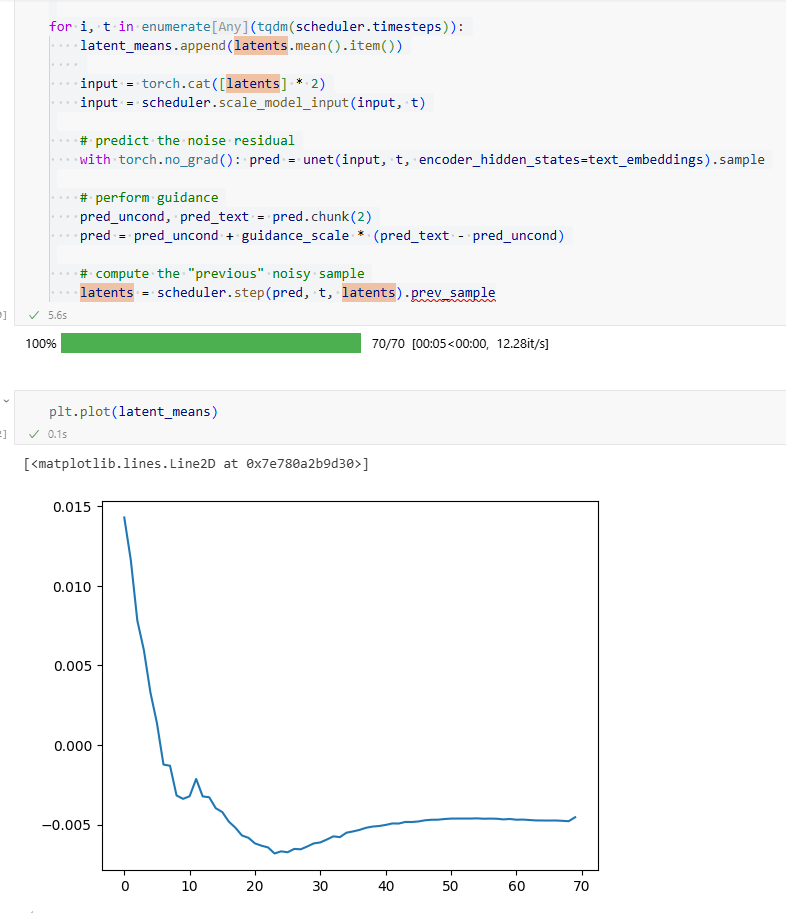


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这个图很有意思！其实这里有两个容易混淆的概念。

`scale_model_input` 保障的不是**均值不变**，而是**方差的量级合适**。它关心的是 U-Net 输入中"信号 vs 噪声"的比例，而不是让 latents 的均值在 0 附近不动。

你看你的图——均值确实在变化，但这不等于方差失控了。而且均值变化是有道理的：

1. **分类器自由引导（CFG）** 会让预测有偏向性，从而逐渐拉偏 latents 的均值
2. 随着去噪进行，从纯噪声（均值为 0）逐渐形成有结构的图像，均值自然也会偏离 0

想验证一下方差吗？可以试试看这样画：

```python
latent_stds = []
for i, t in enumerate(scheduler.timesteps):
    latent_stds.append(latents.std().item())
    # ... 其余循环代码不变
```

然后对比一下调用 `scale_model_input` **之前**和**之后**的 std，看看它到底起了什么作用。要看吗？

<details class='token-usage-details'><summary>$0.0004</summary>

`total=27,775 | in=27,350 | out=425 | cached=95.5% | reasoning=195 | searches=0 | $0.0004`

</details>



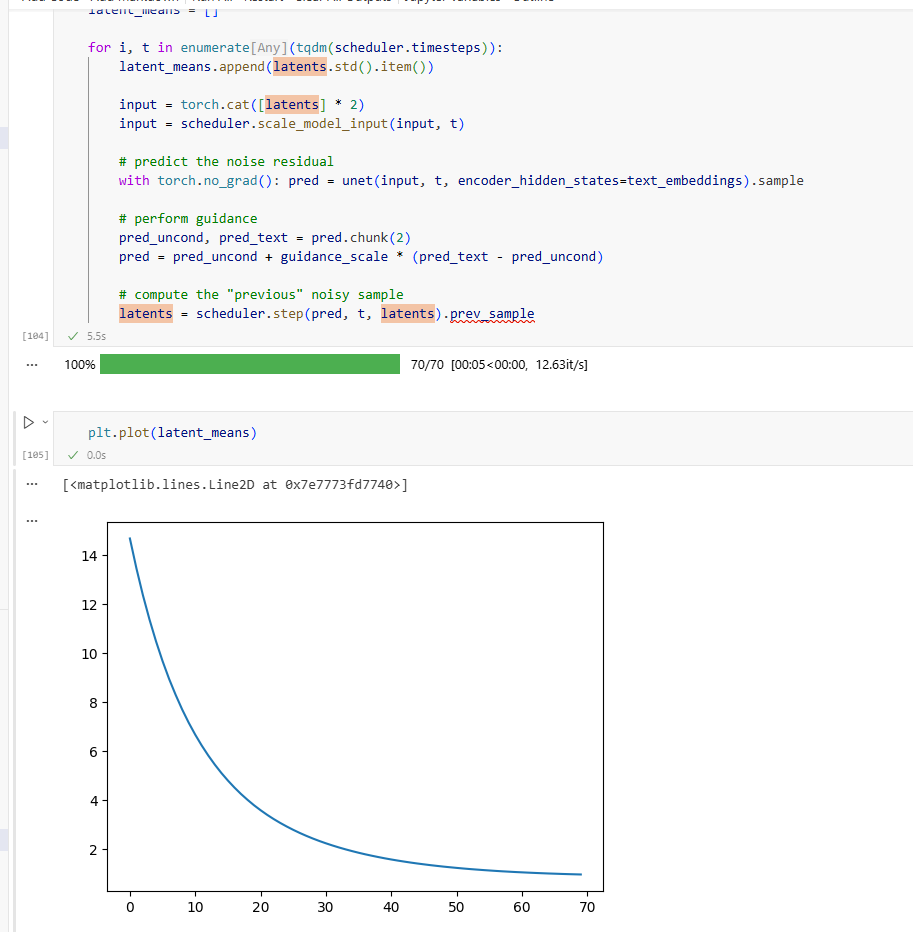


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

有意思！你画了 std 吗？这个图看起来是之前那张均值图。

不过如果我们看到 std 随着去噪过程也在变化，那其实**也是正常的**——这正是扩散过程的本质。扩散模型的完整路径并不是让方差严格恒定，而是一个精心设计的**方差调度（variance schedule）**，让噪声逐渐减少，信号逐渐增多。

`scale_model_input` 做的也不是"让方差纹丝不动"，而是**根据当前时间步的理论噪声水平做一个缩放校正**，让 U-Net 看到的东西和它在训练时看到的分布更一致。但 CFG、调度器本身的更新公式等因素仍然会让 latents 的数值动态变化。

所以——你介意试试把 **std 曲线**画出来（调用 `scale_model_input` 之前），看看它的形状？这样我们还能再深入一步分析调度器在做什么。

<details class='token-usage-details'><summary>$0.0004</summary>

`total=27,937 | in=27,708 | out=229 | cached=94.2% | reasoning=49 | searches=0 | $0.0004`

</details>


Jeremy在课件中是怎么解释这一段的

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

回看那段讲课内容，Jeremy 对缩放这部分其实**没有深入展开**。他提到 `scale_model_input` 时只是说了一句：

> "Something that's very important —we won't worry too much about the details right now— but this, what you'll see here is that we take our random noise and we scale it. And that's because depending on what stage you're up to, you need to make sure that, kind of, you have the right amount of variance, basically, otherwise you're going to get activations and gradients that go out of control."

然后他就跳过去了，说这个会在课程后面讲更多。

所以 Jeremy 当时主要是为了让代码先跑起来，把细节留到后面再深入。你现在自己通过画图来探索这一步的数值行为，其实就是在做他希望大家之后做的事——**真正理解每一步的数值在干什么**。你画了用 `scale_model_input` 前后的 std 对比了吗？如果没画，要不试试看？这样我们就能验证它到底做了什么。

<details class='token-usage-details'><summary>$0.0005</summary>

`total=28,418 | in=27,951 | out=467 | cached=95.3% | reasoning=251 | searches=0 | $0.0005`

</details>


latents不是表示噪声吗，为什么执行完循环后可以表示去噪后的图像

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！这个困惑很常见。

关键在于：`latents` 这个变量**在循环中每步都在被更新**，它存储的是**当前的状态**，而不是固定的"噪声"。整个过程可以这样理解：

- **第 0 步**：latents = 纯噪声
- **第 1 步**：scheduler 从 latents 中减掉一小部分预测出的噪声 → latents 变成了"噪声少了一点点"的版本
- **第 2 步**：在更新后的 latents 上再次预测噪声，再减掉一点点 → 噪声又少了一点
- ...
- **最后一步**：经过几十次减噪声，latents 里的噪声几乎被清空，剩下的就是图像信号

所以 `latents` 是**一个不断演变的变量**，它里面的内容在循环中从"全是噪声"逐渐变成了"几乎全是图像"。就像一块大理石——你一开始看到一块粗糙的石头（噪声），每雕一刀去掉一些多余的石料（减噪声），到最后留下的就是一尊雕像（图像）。

<details class='token-usage-details'><summary>$0.0006</summary>

`total=28,658 | in=28,290 | out=368 | cached=92.3% | reasoning=140 | searches=0 | $0.0006`

</details>


###### end-section

###### Homework

What is the homework?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Looking at the lesson transcript, the suggested homework was to experiment with the simple Stable Diffusion pipeline code that was built during class. The recommendation was to pick one of these extra features to implement yourself:

- **Negative prompts** — the teacher said this would be a nice easy one
- **Image to image** — starting from an existing image rather than pure noise
- **Callbacks** — adding hooks to inspect intermediate results during generation

The key idea is that since you've now built the pipeline code yourself and understand each line, you can extend it without waiting for a library to add features. Would you like some guidance on getting started with any of these, or is there something else you'd like to explore?

<details class='token-usage-details'><summary>$0.0002</summary>

`total=26,760 | in=26,365 | out=395 | cached=99.5% | reasoning=250 | searches=0 | $0.0002`

</details>


Do you recommend I better to do the homework while watching the homework part or watch the whole video, and then do the homework?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great question! I'd suggest a middle path:

1. **Watch the first pass** of the video without stopping too much, to get the big picture. The lesson covers a lot of ground — from papers to pipeline code to building from foundations — and it helps to see how it all connects.

2. **Then go back** to the section where Jeremy builds the simplified pipeline (the part with the three functions that do tokenizing, denoising loop, etc.) and work through that part while tinkering.

3. **That's when** you attempt the homework — negative prompts, image-to-image, or callbacks — because you'll have the full context, but you'll be actively engaging with the code rather than just passively watching.

The risk of trying the homework during a first watch is that you might get bogged down in details and lose the thread of the rest of the lesson. The risk of waiting until after is that you might lose momentum. So: **big picture first, then zoom in.**

Does that approach sound reasonable to you?

<details class='token-usage-details'><summary>$0.0002</summary>

`total=26,833 | in=26,591 | out=242 | cached=98.2% | reasoning=27 | searches=0 | $0.0002`

</details>


Do I need to watch the entire video before starting my homework?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Not necessarily. I'd recommend at least watching through the section where Jeremy builds the simplified pipeline code (the part where he combines everything into a few functions that fit on screen). That's the foundation you'd need for the homework.

Once you've seen that part, you'd have enough context to start working with the code while you watch the rest — or you could pause there, do the homework, and come back to finish the video later.

What sounds better to you?

<details class='token-usage-details'><summary>$0.0002</summary>

`total=27,003 | in=26,874 | out=129 | cached=97.2% | reasoning=33 | searches=0 | $0.0002`

</details>


Let's do the homework for negative prompts. What is its principle?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great question! The principle behind negative prompts is an extension of **Classifier-Free Guidance (CFG)**.

Here's the core idea. In standard CFG, the U-Net makes two predictions:

1. **`u`** — what the image looks like with no prompt at all (unconditional)
2. **`c`** — what the image looks like with your prompt (conditional)

We then combine them like this:

> final prediction = `u` + guidance_scale × (`c` − `u`)

This pushes the result *away from* the unconditional direction and *toward* your prompt.

---

A **negative prompt** adds a third prediction:

3. **`n`** — what the image looks like with the *negative* prompt (what you *don't* want)

The equation becomes:

> final prediction = `u` + guidance_scale × (`c` − `u`) + negative_scale × (`u` − `n`)

The new term (`u` − `n`) pushes the result away from the negative concept. So if you prompt "red car" with a negative prompt of "blue", the model will avoid blue tones.

---

In code terms, you'd just need to:

- Run the U-Net three times instead of two (unconditional, positive, negative)
- Add one more term to the combination step

Does that make sense? Want to try sketching out how you'd modify the pipeline code to add this?

<details class='token-usage-details'><summary>$0.0004</summary>

`total=27,564 | in=27,000 | out=564 | cached=96.7% | reasoning=258 | searches=0 | $0.0004`

</details>


What was the negative scale in the original paper?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That's a sharp question — and the answer is a bit interesting: **negative prompts weren't actually introduced in an academic paper.** They're a practical invention that emerged from the Stable Diffusion community.

The original **CFG paper** ("Classifier-Free Diffusion Guidance", Ho & Salimans 2021) only defines the two-term equation I showed:

> `u` + guidance_scale × (`c` − `u`)

The idea of adding a *third* term with an explicit "negative prompt" came later, popularized by tools like **Automatic1111's Stable Diffusion WebUI** and **InvokeAI**. These tools let you enter a separate prompt for what you want to avoid, and they apply a similar guidance-style scaling.

So there isn't a canonical "negative scale" from a paper. In practice, tools typically:

- Reuse the **same guidance scale** for both the positive and negative terms, or
- Let you set it independently (sometimes called "negative guidance scale" or just use the same CFG scale)

If you wanted to implement it yourself, a reasonable default would be to use the same guidance scale for both terms, and then experiment from there. Would you like to try coding it up?

<details class='token-usage-details'><summary>$0.0005</summary>

`total=27,876 | in=27,372 | out=504 | cached=95.4% | reasoning=251 | searches=0 | $0.0005`

</details>


What is the negative_scale default value in the diffusers library?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let me check the diffusers library to give you an accurate answer.


<details class='tool-usage-details'>
<summary><code>read_url(url=&#x27;https://huggingface.co/docs/diffusers/ma…&#x27;, selector=&#x27;#parameters&#x27;)→&#x27;No output&#x27;</code></summary>

```json
{
  "id": "call_00_tC1hPnrayThwLxCIyNG02066",
  "call": {
    "function": "read_url",
    "arguments": {
      "url": "https://huggingface.co/docs/diffusers/main/en/api/pipelines/stable_diffusion/text2img#diffusers.StableDiffusionPipeline.__call__",
      "selector": "#parameters"
    }
  },
  "result": "No output"
}
```

</details>








<details class='tool-usage-details'>
<summary><code>read_url(url=&#x27;https://huggingface.co/docs/diffusers/ma…&#x27;)→&quot;[![Hugging Face&#x27;s logo](https://huggingf…&quot;</code></summary>

```json
{
  "id": "call_00_FdE2olW4yqKlAKHEuh1s3420",
  "call": {
    "function": "read_url",
    "arguments": {
      "url": "https://huggingface.co/docs/diffusers/main/en/api/pipelines/stable_diffusion/text2img"
    }
  },
  "result": "<TRUNCATED>\u2026 Face's logo](https://huggingface.co/front/assets/huggingface_logo-noborder.svg) Hugging Face](/)\n\n  * [ Models ](/models)\n  * [ Datasets ](/datasets)\n  * [ Spaces ](/spaces)\n  * [ Buckets new](/storage)\n  * [ Docs ](/docs)\n  * [ Enterprise ](/enterprise)\n  * [Pricing](/pricing)\n  *   * * * *\n\n  * [Log In](/login)\n  * [Sign Up](/join)\n\n\n\nDiffusers documentation\n\nText-to-image\n\n# Diffusers\n\n\ud83c\udfe1 View all docsAWS Trainium & InferentiaAccelerateArgillaAutoTrainBitsandbytesCLIChat UIDataset viewerDatasetsDeploying on AWSDiffusersDistilabelEvaluateGoogle CloudGoogle TPUsGradioHubHub Python LibraryHuggingface.jsInference Endpoints (dedicated)Inference ProvidersKernelsLeRobotLeaderboardsLightevalMicrosoft AzureOptimumPEFTReachy MiniSafetensorsSentence TransformersTRLTasksText Embeddings InferenceText Generation InferenceTokenizersTrackioTransformersTransformers.jsXetsmolagentstimm\n\nSearch documentation\n\nmainv0.38.0v0.37.1v0.36.0v0.35.1v0.34.0v0.33.1v0.32.2v0.31.0v0.30.3v0.29.2v0.28.2v0.27.2v0.26.3v0.25.1v0.24.0v0.23.1v0.22.3v0.21.0v0.20.0v0.19.3v0.18.2v0.17.1v0.16.0v0.15.0v0.14.0v0.13.0v0.12.0v0.11.0v0.10.2v0.9.0v0.8.0v0.7.0v0.6.0v0.5.1v0.4.1v0.3.0v0.2.4 ENJAKOPTZH\n\n[ ](https://github.com/huggingface/diffusers)\n\nGet started\n\n[Diffusers](/docs/diffusers/main/en/index)[Installation](/docs/diffusers/main/en/installation)[Quickstart](/docs/diffusers/main/en/quicktour)[Basic performance](/docs/diffusers/main/en/stable_diffusion)\n\nPipelines\n\nAdapters\n\nInference\n\nInference optimization\n\nModular Diffusers\n\nTraining\n\nQuantization\n\nModel accelerators and hardware\n\nSpecific pipeline examples\n\nResources\n\nAPI\n\nMain Classes\n\nModular\n\nLoaders\n\nModels\n\nPipelines\n\n[Overview](/docs/diffusers/main/en/api/pipelines/overview)[AutoPipeline](/docs/diffusers/main/en/api/pipelines/auto_pipeline)\n\nAudio\n\nImage\n\n[AnimateDiff](/docs/diffusers/main/en/api/pipelines/animatediff)[AuraFlow](/docs/diffusers/main/en/api/pipelines/aura_flow)[Bria 3.2](/docs/diffusers/main/en/api/pipelines/bria_3_2)[Bria Fibo](/docs/diffusers/main/en/api/pipelines/bria_fibo)[Bria Fibo Edit](/docs/diffusers/main/en/api/pipelines/bria_fibo_edit)[Chroma](/docs/diffusers/main/en/api/pipelines/chroma)[CogView3](/docs/diffusers/main/en/api/pipelines/cogview3)[CogView4](/docs/diffusers/main/en/api/pipelines/cogview4)[Consistency Models](/docs/diffusers/main/en/api/pipelines/consistency_models)[ControlNet](/docs/diffusers/main/en/api/pipelines/controlnet)[ControlNet with Flux.1](/docs/diffusers/main/en/api/pipelines/controlnet_flux)[ControlNet with Hunyuan-DiT](/docs/diffusers/main/en/api/pipelines/controlnet_hunyuandit)[ControlNet with Stable Diffusion 3](/docs/diffusers/main/en/api/pipelines/controlnet_sd3)[ControlNet with Stable Diffusion XL](/docs/diffusers/main/en/api/pipelines/controlnet_sdxl)[ControlNet-Sana](/docs/diffusers/main/en/api/pipelines/controlnet_sana)[ControlNetUnion](/docs/diffusers/main/en/api/pipelines/controlnet_union)[DDIM](/docs/diffusers/main/en/api/pipelines/ddim)[DDPM](/docs/diffusers/main/en/api/pipelines/ddpm)[DeepFloyd IF](/docs/diffusers/main/en/api/pipelines/deepfloyd_if)[DiT](/docs/diffusers/main/en/api/pipelines/dit)[EasyAnimate](/docs/diffusers/main/en/api/pipelines/easyanimate)[ERNIE-Image](/docs/diffusers/main/en/api/pipelines/ernie_image)[Flux](/docs/diffusers/main/en/api/pipelines/flux)[Flux2](/docs/diffusers/main/en/api/pipelines/flux2)[FluxControlInpaint](/docs/diffusers/main/en/api/pipelines/control_flux_inpaint)[GLM-Image](/docs/diffusers/main/en/api/pipelines/glm_image)[HiDream-I1](/docs/diffusers/main/en/api/pipelines/hidream)[Hunyuan-DiT](/docs/diffusers/main/en/api/pipelines/hunyuandit)[HunyuanImage2.1](/docs/diffusers/main/en/api/pipelines/hunyuanimage21)[InstructPix2Pix](/docs/diffusers/main/en/api/pipelines/pix2pix)[Kandinsky 2.1](/docs/diffusers/main/en/api/pipelines/kandinsky)[Kandinsky 2.2](/docs/diffusers/main/en/api/pipelines/kandinsky_v22)[Kandinsky 3](/docs/diffusers/main/en/api/pipelines/kandinsky3)[Kandinsky 5.0 Image](/docs/diffusers/main/en/api/pipelines/kandinsky5_image)[Kolors](/docs/diffusers/main/en/api/pipelines/kolors)[Latent Consistency Models](/docs/diffusers/main/en/api/pipelines/latent_consistency_models)[Latent Diffusion](/docs/diffusers/main/en/api/pipelines/latent_diffusion)[LEDITS++](/docs/diffusers/main/en/api/pipelines/ledits_pp)[LongCat-Image](/docs/diffusers/main/en/api/pipelines/longcat_image)[Lumina 2.0](\u2026</TRUNCATED>"
}
```

</details>





From the diffusers docs, I can see there's **no separate `negative_scale` parameter**. The `StableDiffusionPipeline.__call__` only has:

- `guidance_scale` (default: 7.5)
- `negative_prompt` (optional)

In diffusers, negative prompts are handled using the **same** `guidance_scale` — there isn't a separate scaling factor. The pipeline encodes the negative prompt and uses it alongside the unconditional (empty) embedding within the standard CFG equation.

So if you want to use a negative prompt in the built-in pipeline, you'd just do:

```python
pipe("a red car", negative_prompt="blue")
```

And it applies the same guidance scale to both the positive and negative guidance.

Would you like to look at how it actually combines them under the hood?

<details class='token-usage-details'><summary>$0.0028</summary>

`total=96,301 | in=95,619 | out=682 | cached=87.3% | reasoning=330 | searches=0 | $0.0028`

</details>


https://github.com/huggingface/diffusers/blob/main/src/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py

find the result

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

<details class='tool-usage-details'>
<summary><code>read_url(url=&#x27;https://github.com/huggingface/diffusers…&#x27;)→&#x27;# Copyright 2025 The HuggingFace Team. A…&#x27;</code></summary>

```json
{
  "id": "call_00_EhZtc60VNqtIBTnPCrYc3624",
  "call": {
    "function": "read_url",
    "arguments": {
      "url": "https://github.com/huggingface/diffusers/blob/main/src/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py"
    }
  },
  "result": "<TRUNCATED>\u2026t 2025 The HuggingFace Team. All rights reserved.\n#\n# Licensed under the Apache License, Version 2.0 (the \"License\");\n# you may not use this file except in compliance with the License.\n# You may obtain a copy of the License at\n#\n#     http://www.apache.org/licenses/LICENSE-2.0\n#\n# Unless required by applicable law or agreed to in writing, software\n# distributed under the License is distributed on an \"AS IS\" BASIS,\n# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n# See the License for the specific language governing permissions and\n# limitations under the License.\nimport inspect\nfrom typing import Any, Callable\n\nimport torch\nfrom packaging import version\nfrom transformers import CLIPImageProcessor, CLIPTextModel, CLIPTokenizer, CLIPVisionModelWithProjection\n\nfrom ...callbacks import MultiPipelineCallbacks, PipelineCallback\nfrom ...configuration_utils import FrozenDict\nfrom ...image_processor import PipelineImageInput, VaeImageProcessor\nfrom ...loaders import FromSingleFileMixin, IPAdapterMixin, StableDiffusionLoraLoaderMixin, TextualInversionLoaderMixin\nfrom ...models import AutoencoderKL, ImageProjection, UNet2DConditionModel\nfrom ...models.lora import adjust_lora_scale_text_encoder\nfrom ...schedulers import KarrasDiffusionSchedulers\nfrom ...utils import (\n    USE_PEFT_BACKEND,\n    deprecate,\n    is_torch_xla_available,\n    logging,\n    replace_example_docstring,\n    scale_lora_layers,\n    unscale_lora_layers,\n)\nfrom ...utils.torch_utils import randn_tensor\nfrom ..pipeline_utils import DiffusionPipeline, StableDiffusionMixin\nfrom .pipeline_output import StableDiffusionPipelineOutput\nfrom .safety_checker import StableDiffusionSafetyChecker\n\n\nif is_torch_xla_available():\n    import torch_xla.core.xla_model as xm\n\n    XLA_AVAILABLE = True\nelse:\n    XLA_AVAILABLE = False\n\nlogger = logging.get_logger(__name__)  # pylint: disable=invalid-name\n\nEXAMPLE_DOC_STRING = \"\"\"\n    Examples:\n        ```py\n        >>> import torch\n        >>> from diffusers import StableDiffusionPipeline\n\n        >>> pipe = StableDiffusionPipeline.from_pretrained(\n        ...     \"stable-diffusion-v1-5/stable-diffusion-v1-5\", torch_dtype=torch.float16\n        ... )\n        >>> pipe = pipe.to(\"cuda\")\n\n        >>> prompt = \"a photo of an astronaut riding a horse on mars\"\n        >>> image = pipe(prompt).images[0]\n        ```\n\"\"\"\n\n\ndef rescale_noise_cfg(noise_cfg, noise_pred_text, guidance_rescale=0.0):\n    r\"\"\"\n    Rescales `noise_cfg` tensor based on `guidance_rescale` to improve image quality and fix overexposure. Based on\n    Section 3.4 from [Common Diffusion Noise Schedules and Sample Steps are\n    Flawed](https://huggingface.co/papers/2305.08891).\n\n    Args:\n        noise_cfg (`torch.Tensor`):\n            The predicted noise tensor for the guided diffusion process.\n        noise_pred_text (`torch.Tensor`):\n            The predicted noise tensor for the text-guided diffusion process.\n        guidance_rescale (`float`, *optional*, defaults to 0.0):\n            A rescale factor applied to the noise predictions.\n\n    Returns:\n        noise_cfg (`torch.Tensor`): The rescaled noise prediction tensor.\n    \"\"\"\n    std_text = noise_pred_text.std(dim=list(range(1, noise_pred_text.ndim)), keepdim=True)\n    std_cfg = noise_cfg.std(dim=list(range(1, noise_cfg.ndim)), keepdim=True)\n    # rescale the results from guidance (fixes overexposure)\n    noise_pred_rescaled = noise_cfg * (std_text / std_cfg)\n    # mix with the original results from guidance by factor guidance_rescale to avoid \"plain looking\" images\n    noise_cfg = guidance_rescale * noise_pred_rescaled + (1 - guidance_rescale) * noise_cfg\n    return noise_cfg\n\n\ndef retrieve_timesteps(\n    scheduler,\n    num_inference_steps: int | None = None,\n    device: str | torch.device | None = None,\n    timesteps: list[int] | None = None,\n    sigmas: list[float] | None = None,\n    **kwargs,\n):\n    r\"\"\"\n    Calls the scheduler's `set_timesteps` method and retrieves timesteps from the scheduler after the call. Handles\n    custom timesteps. Any kwargs will be supplied to `scheduler.set_timesteps`.\n\n    Args:\n        scheduler (`SchedulerMixin`):\n            The scheduler to get timesteps from.\n        num_inference_steps (`int`):\n            The number of diffusion steps used when generating samples with a pre-trained model. If used, `timesteps`\n            must be `None`.\n        device (`str` or `torch.device`, *optional*):\n            The device to which the timesteps should be moved to. If `None`, the timesteps are not moved.\n        timesteps (`list[int]`, *optional*):\n            Custom timesteps used to override the timestep spacing strategy of the scheduler. If `timesteps` is passed,\n            `num_inference_steps` and `sigmas` must be `None`.\n        sigmas (`list[float]`, *optional*):\n            Custom sigmas used to override the timestep spacing strategy of the scheduler. If `sigmas` is passed,\n            `num_inference_steps` and `timesteps` must\u2026</TRUNCATED>"
}
```

</details>





Found it! Here's the key part. In the denoising loop (around line 710–720):

```python
noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
noise_pred = noise_pred_uncond + self.guidance_scale * (noise_pred_text - noise_pred_uncond)
```

And before that, when preparing the prompt embeddings (around line 636):

```python
prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds])
```

So here's how diffusers handles it: **the negative prompt replaces the empty/unconditional prompt entirely.** Instead of:

> `u` + guidance_scale × (`c` − `u`)

where `u` is the empty string embedding, it becomes:

> `n` + guidance_scale × (`c` − `n`)

where `n` is your negative prompt embedding. This directly pushes the result *away* from the negative concept. And there's **no separate negative scale** — the same `guidance_scale` is applied.

Does this help you see where you'd need to modify your own pipeline code to add negative prompts?

<details class='token-usage-details'><summary>$0.0036</summary>

`total=73,411 | in=72,638 | out=773 | cached=78.2% | reasoning=451 | searches=0 | $0.0036`

</details>


can we use a prompt with negative prompt Together

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes! When you pass both, the pipeline does:

```python
prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds])
```

It puts both into the U-Net in a single batch, then separates the results. The equation becomes:

> `n` + guidance_scale × (`c` − `n`)

This pushes the result **toward** your prompt and **away from** the negative prompt — all in one step.

So `pipe("a red car", negative_prompt="blue")` would try to make a red car while actively avoiding anything blue.

Want to try a quick example in code?

<details class='token-usage-details'><summary>$0.0009</summary>

`total=31,550 | in=31,304 | out=246 | cached=87.5% | reasoning=108 | searches=0 | $0.0009`

</details>


how to do image2image

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Image-to-image starts with an **existing image** and denoises *from there*, rather than from pure random noise.

The key difference: instead of starting with a random latent sampled from N(0,1), you:

1. Encode your input image through the VAE to get latents
2. Add **noise** to those latents — how much noise depends on a parameter called `strength`
3. Start the denoising loop from that noisy latent, using your prompt

The `strength` parameter (0 to 1) controls how much of the original image is preserved:
- `strength=0` → nothing changes (no noise added)
- `strength=1` → complete replacement (pure noise, like text-to-image)
- `strength=0.6` → roughly 60% of the original details are replaced

In your pipeline code, the main change would be in how you initialize the latents. Instead of `randn_tensor(...)`, you'd encode the image, add noise to it, and start the loop from a later timestep.

Do you want to look at the specific changes to the denoising loop code side by side?

<details class='token-usage-details'><summary>$0.0011</summary>

`total=31,738 | in=31,394 | out=344 | cached=85.2% | reasoning=94 | searches=0 | $0.0011`

</details>


###### end-section

###### clip

Why do we need the text encoder and clip encoder together

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great question! Let's clear up what's actually going on, because the terminology can be confusing.

In the Stable Diffusion pipeline, there's really just **one text encoder** — it's the text encoder *from* CLIP. But getting text into it involves **two steps**:

---

**Step 1: Tokenizer**

The tokenizer takes your written prompt like `"a photograph of an astronaut riding a horse"` and converts it into a sequence of numbers (token IDs). Each number represents a word or sub-word from a fixed vocabulary. For example, `"a"` might become token `32`, `"photo"` might become `1387`, etc.

**Step 2: CLIP Text Encoder**

This is a neural network that takes those token IDs and turns them into **embeddings** — dense vectors of floating-point numbers (768 numbers per token, in this case). These embeddings capture the *meaning* of your prompt in a way the U-Net can understand.

The key insight: the CLIP text encoder was trained alongside a CLIP *image* encoder using that contrastive loss Jeremy described — matching text embeddings to image embeddings of the same thing. So when you run `"astronaut riding a horse"` through the text encoder, it produces an embedding that's close (in vector space) to the embedding of actual astronaut-on-horse photos.

---

**Why not skip the tokenizer?**

You could, in theory, design a model that takes characters directly — but tokenization is a useful preprocessing step. It turns variable-length text into fixed-size integer sequences that the neural net can efficiently process.

**Why the "CLIP" part matters?**

Because the text encoder was trained as part of CLIP's contrastive learning, it's learned to place descriptions and images into a shared embedding space. That's exactly what we need for text-to-image generation: we want the model to understand that the embedding for `"a cute puppy"` should guide the image generation toward something that looks like a cute puppy.

---

Does that help clarify things? Want to dig deeper into how the CLIP training actually works, or how those embeddings get fed into the U-Net?

<details class='token-usage-details'><summary>$0.0004</summary>

`total=27,189 | in=26,373 | out=816 | cached=99.5% | reasoning=364 | searches=0 | $0.0004`

</details>


So what does it mean when Jamie said "we've talked about: the text encoder, the clip encoder, the VAE and the U-Net. So there they are"

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That's a great spot — the quote is a bit confusing because he mentions four things but calls them "three models." Here's what I think is going on.

Jeremy is actually referring to **three main model components**, but he mentions the text encoder twice with slightly different descriptions:

1. **The CLIP text encoder** (he calls it both "the text encoder" and "the clip encoder" — same thing)
2. **The VAE** (the autoencoder that compresses images to and from latent space)
3. **The U-Net** (the core diffusion model that predicts the noise)

So when he says "the text encoder, the clip encoder" he's accidentally saying the same component twice, just with different words. It's easy to do when speaking live!

Here's what those three models actually do:

| Model | Job |
|---|---|
| **CLIP text encoder** | Turns your prompt into meaningful embeddings the U-Net can understand |
| **VAE** | Compresses images 8× smaller so the U-Net can work much faster |
| **U-Net** | The main workhorse — predicts noise and gradually denoises the image |

Do you want to look at how these three connect together in the actual code from the notebook?

<details class='token-usage-details'><summary>$0.0006</summary>

`total=27,868 | in=26,917 | out=951 | cached=97.0% | reasoning=689 | searches=0 | $0.0006`

</details>


###### end-section

###### Textual inversion

什么是Textual inversion

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Textual inversion（文本反演）是扩散模型中的一项重要技术，它让你能用几张示例图片，教会模型一个**新的概念/词**。

具体来说是这样：

### 核心思路

假设你想生成自己家小狗的图片，但“我的狗”这个描述对 Stable Diffusion 来说是陌生的，它不知道长什么样。Textual inversion 的做法是：

1. **选几张你的小狗的照片**（比如 3-5 张）
2. **冻结整个模型**（U-Net、VAE、CLIP 文本编码器全部不动）
3. **在文本编码器的 embedding 空间中**，新增一个虚拟的 token（比如叫 `*dog`），然后只优化这个 token 对应的 embedding 向量
4. **优化目标**：让 `"一张 *dog 的照片" → U-Net → 生成图片` 的结果，尽量接近你的小狗照片

训练完成后，这个 `*dog` 的 embedding 就"记住"了你家狗的特征。之后你就可以写：
> `"*dog 在公园里奔跑"`  
> `"*dog 的油画肖像"`

来生成你自家小狗在不同场景下的图片了。

### 对比刚才视频里讲的 Imagic

Imagic 是 textual inversion 的进阶版：
- Textual inversion：只优化 embedding，**模型不动**
- Imagic：先优化 embedding（像 textual inversion），**然后解冻并微调整个模型**，最后在两个 embedding 之间做插值

### 一个直观比喻

可以把 embedding 想象成一个"坐标点"。普通词如"狗"在 embedding 空间中有一个位置。Textual inversion 就是在空间中找一个**新位置**，这个位置能代表你家那只特定的狗——而整个"地图"（模型的其他参数）保持不变。

---

你们在接触 Stable Diffusion 基础后，想试试用代码实现一个简单的 textual inversion 吗？还是想深入理解它的数学原理？

<details class='token-usage-details'><summary>$0.0052</summary>

`total=27,050 | in=26,366 | out=684 | cached=10.7% | reasoning=277 | searches=0 | $0.0052`

</details>


How does a text encoder combine the embeddings of a sentence?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！CLIP 的文本编码器使用 Transformer 架构来处理句子，大致分这几步：

### 1. 分词（Tokenization）
先把句子拆成 token（词或子词），例如：
> `"a photograph of an astronaut"` → `[a, photograph, of, an, astronaut]`

每个 token 加上一个特殊的 `[SOS]`（句首）和 `[EOS]`（句尾）标记，并 padding 到固定长度（CLIP 用的是 77）。

### 2. 查表得到初始向量
每个 token 从一个**嵌入表**里查出它对应的向量（比如 768 维）。这时你得到的是：
- 一个形状为 `[77, 768]` 的矩阵
- 但这 77 个向量彼此是**独立的**——每个 token 还不知道它周围的上下文

### 3. 加上位置编码
给每个位置加上一个位置向量，让模型知道 token 的顺序。

### 4. 经过 Transformer 层
这是关键。多层 Transformer 的**自注意力机制**让每个 token "看到"其他所有 token，从而产生上下文相关的表示。例如，"bank" 在 "river bank" 和 "bank account" 中会得到完全不同的向量。

### 5. 提取句子向量
CLIP 并没有对所有 token 向量取平均。它使用 `[EOS]`（句尾）token 位置最终输出的向量，作为**整个句子的嵌入**。

所以这个过程可以想象成：
- 每个 token 先独自"站好"
- 然后通过自注意力互相"交流"、理解上下文
- 最后 `[EOS]` 标记"听完"所有信息后，输出一个浓缩了整个句子语义的向量

---

你想深入看一下自注意力是如何让 token 之间"交流"的吗？或者我们用手头的 Python 环境，实际观察一下 CLIP 编码一个句子的中间结果？

<details class='token-usage-details'><summary>$0.0053</summary>

`total=27,521 | in=26,839 | out=682 | cached=10.5% | reasoning=266 | searches=0 | $0.0053`

</details>


What is the shape of the final extracted sentence vectors?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

对于 CLIP 文本编码器（`ViT-L/14`，即 Stable Diffusion 常用的版本）：

### 完整输出
- 你得到的是一个形状为 **`[77, 768]`** 的矩阵
- 那 77 行对应每个 token 位置（句首、全部 token、句尾、padding 位）
- 768 列是每个 token 的嵌入维度

### 最终句子向量
从这 77 个向量中取出**句尾 `[EOS]` 位置**的那一个向量，形状就是 **`[768]`**（一个 1D 向量）。

### 批处理时
如果同时编码多个句子（比如做 classifier-free guidance 时需要同时编码 prompt 和空字符串），你可能会看到形状变为：
- `[2, 77, 768]`——两个句子，每个有 77 个 token 位置
- 然后取出每个句子的 `[EOS]` 后得到 `[2, 768]`

---

这 768 维的向量就是你传给 U-Net 的"条件信号"。想知道它长什么样吗？比如我们可以拿一个 prompt，用 Python 实际查看这个向量的一些统计信息。

<details class='token-usage-details'><summary>$0.0004</summary>

`total=27,674 | in=27,320 | out=354 | cached=95.6% | reasoning=92 | searches=0 | $0.0004`

</details>


###### end-section

###### Classifier Free Guided Diffusion Models

What's "Classifier Free Guided Diffusion Models" mean

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

**Classifier-Free Guided Diffusion** is a trick for making a diffusion model follow your prompt more strongly.

In plain English:

- The model learns to predict noise in two situations:
  - **with a prompt** like “a cute puppy”
  - **with no prompt** at all
- At generation time, it combines those two predictions.
- By turning up the **guidance scale**, you tell the model:  
  “Stay closer to the prompt.”

Why “classifier-free”?

- Older methods used a separate **classifier** to guide generation.
- This method does **not** need that extra classifier.
- The diffusion model guides itself using the prompt-conditioned and unconditional predictions.

A good mental picture is:

- **unconditional prediction** = “what image seems likely in general?”
- **prompted prediction** = “what image matches the text?”
- **guidance** = “lean more toward the text one”

That’s why increasing guidance often makes images look more like the prompt, though too much can make them look weird or overcooked.

<details class='token-usage-details'><summary>$0.0064</summary>

`total=30,126 | in=29,687 | out=439 | cached=99.6% | reasoning=219 | searches=0 | $0.0064`

</details>


What are the older methods?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The main older method was **classifier guidance**.

Very roughly:

- You trained a **separate classifier** to tell what class an image belongs to.
- During diffusion sampling, you used the classifier’s gradient to push the image toward the desired class.
- So if you wanted “a dog,” the classifier helped steer the denoising process toward dog-like outputs.

Why classifier-free guidance was a big deal:

- It **doesn’t need a separate classifier**
- It’s simpler to train and use
- It usually works better in practice

So the progression is:

1. **No guidance** — just generate from noise  
2. **Classifier guidance** — use an extra classifier to steer the result  
3. **Classifier-free guidance** — steer using the diffusion model itself

<details class='token-usage-details'><summary>$0.0061</summary>

`total=30,229 | in=29,965 | out=264 | cached=97.0% | reasoning=99 | searches=0 | $0.0061`

</details>


###### end-section

###### distillation

解释下Jeremy讲的SD 蒸馏原理，怎么一步步训练出来最终的Student model

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

可以，把 Jeremy 讲的这个 **Stable Diffusion 蒸馏（distillation）** 理解成一句话就是：

**把“慢慢去噪很多步的 Teacher 模型”，训练成“少走几步、甚至一步到位的 Student 模型”。**

我分成 4 步讲最清楚：

1. **先有一个已经训练好的 Teacher**
   - 它本身就是一个完整的 Stable Diffusion 去噪模型。
   - 你给它一团噪声，它可以经过很多次 U-Net 去噪，慢慢变成清晰图像。
   - 但缺点是：**慢**，比如 60 步、100 步，甚至更多。

2. **拿 Teacher 当“答案机器”**
   - 训练 Student 时，不是让它直接学最终图片，而是让它学：
     > “如果 Teacher 走了 2 步以后会变成什么样？”
   - 这样 Student 的输入是“噪声/中间状态”，输出是 Teacher 走完几步后的结果。
   - 训练目标通常就是让 Student 的输出和 Teacher 的输出尽量接近，比如用 MSE。

3. **先学会跳 2 步，再跳 4 步、8 步……**
   - 这是 Jeremy 讲的核心：**progressive distillation**。
   - 第一次：
     - Teacher 走 2 个去噪步骤
     - Student 学会“直接模拟这 2 步后的结果”
   - 第二次：
     - 把刚训练好的 Student 暂时当新 Teacher
     - 再让新的 Student 学会“一次抵 4 步”
   - 然后继续：
     - 4 步 → 8 步
     - 8 步 → 16 步
     - 16 步 → 32 步
   - 这样就像把“多次小跨步”压缩成“少数大跨步”。

4. **最后得到一个很快的 Student**
   - 经过多轮蒸馏后，Student 不再需要那么多去噪迭代。
   - 原来要 60 步，现在可能只要 4 步就能出图。
   - 速度大幅提升，但图像质量尽量保持接近 Teacher。

你可以把它想成：

- **Teacher**：老练画师，慢慢修图
- **Student**：学徒，学会“快速模仿老师最后的效果”
- 蒸馏的过程：不是教学生每一笔怎么画，而是教他**从中间状态直接跳到更接近成品的状态**

如果再说得更数学一点，训练就是在做这种事：

- 输入：噪声图 / 中间 latent / prompt / guidance
- 目标：Teacher 多走几步后的结果
- 损失：Student 输出和 Teacher 输出的差距
- 反复训练后，Student 学会更大的“步长”

Jeremy 讲的这个方法厉害的地方在于：

- 不需要重新从零训练一个生成模型
- 而是利用已经很强的 Teacher
- 把“长链条采样”压缩成“短链条采样”

如果你愿意，我下一步可以把它画成一个 **“从 60 步压到 4 步”的流程图**，会更直观。

<details class='token-usage-details'><summary>$0.0393</summary>

`total=30,570 | in=29,699 | out=871 | cached=0.0% | reasoning=110 | searches=0 | $0.0393`

</details>


Why not directly train the student model to skip sixteen steps or thirty-two steps?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Because it gets **much harder to learn a very large jump in one go**.

A good way to think about it:

- **Skipping 2 steps is easy-ish**: the student only needs to imitate a small amount of denoising.
- **Skipping 16 or 32 steps is much harder**: the student has to predict a much more complex transformation from a much noisier input, so mistakes compound quickly.
- **Training becomes unstable**: the model is trying to learn a big “macro move” before it has mastered the smaller ones.
- **Progressive distillation acts like a curriculum**: 2 steps → 4 steps → 8 steps → 16 steps. Each stage is easier because the previous student has already learned a good approximation.

So yes, in principle you *can* try to train a student to skip 16 or 32 steps directly, but in practice it’s often **harder to optimize**, **less accurate**, and **more likely to produce ugly images** than training it gradually.

The key idea is:  
**big jumps are possible only after the model has learned how to make smaller jumps reliably.**

<details class='token-usage-details'><summary>$0.0074</summary>

`total=30,895 | in=30,528 | out=367 | cached=95.2% | reasoning=126 | searches=0 | $0.0074`

</details>


###### end-section

###### spherical linear interpolation

So @puru did some, something interesting, which is to create a bunch of images, of doing a linear interpolation —I mean, detail is actually spherical linear interpolation but it doesn't matter

How does linear interpolation work?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Linear interpolation means: **blend between two values in a straight line**.

If you have two points or vectors, `A` and `B`, then for a mixing amount `t` between 0 and 1:

\[
\text{lerp}(A, B, t) = (1-t)A + tB
\]

- `t = 0` gives you `A`
- `t = 1` gives you `B`
- `t = 0.5` gives the halfway point

For images or latent vectors, you do this element-by-element, so the result gradually changes from one image to the other.

A simple example:
- start vector: `[0, 0]`
- end vector: `[10, 20]`

At `t = 0.25`:

\[
(1-0.25)[0,0] + 0.25[10,20] = [2.5, 5]
\]

In diffusion models, this is often used to create a smooth transition between two latent codes. If the vectors are on a sphere, people sometimes use **slerp** instead, which keeps the path on the sphere rather than in a straight line.

<details class='token-usage-details'><summary>$0.0362</summary>

`total=30,130 | in=29,717 | out=413 | cached=0.0% | reasoning=153 | searches=0 | $0.0362`

</details>


What does ' the vectors are on a sphere' mean

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

It means the vectors are being treated as points that all have the **same distance from the origin**.

In 2D, that “sphere” is actually a **circle**. In 3D, it’s the usual sphere.  
In higher dimensions, mathematicians still call it a sphere.

So if two latent vectors lie on a sphere, they have the same **length** or **norm**, and moving between them while staying on the sphere means you’re not changing that length — you’re moving along the curved surface instead of cutting straight through the middle.

<details class='token-usage-details'><summary>$0.0056</summary>

`total=30,217 | in=30,042 | out=175 | cached=96.7% | reasoning=55 | searches=0 | $0.0056`

</details>


So why can we use it in diffusion model

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Because the **latent space is continuous** and the decoder can turn nearby points into **similar images**.

So if you take two latent vectors from a diffusion model, interpolating between them gives a smooth path through image space:
- one end looks like image A
- the middle looks like a blend
- the other end looks like image B

That works especially well because diffusion latents are usually modeled as **random Gaussian-like vectors**, so moving smoothly between them often stays in a “reasonable” part of the space.

If the vectors are on a sphere, **slerp** is often better than plain linear interpolation because it keeps the vector length about the same, which can make the intermediate samples look more natural.

In short: we use it because **small moves in latent space usually mean small, smooth changes in the generated image**.

<details class='token-usage-details'><summary>$0.0072</summary>

`total=30,686 | in=30,227 | out=459 | cached=97.8% | reasoning=283 | searches=0 | $0.0072`

</details>


SD的向量是在球面上吗，怎么理解

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

不一定。**Stable Diffusion 里的向量通常不是“严格在球面上”**，但你可以把它**近似理解成**：很多向量都在一个“差不多固定长度”的空间里活动。

可以这样想：

- **球面**：所有点到原点的距离都一样
- **向量长度固定**：就是这个意思
- **在高维里**，这种“固定长度的点集”也叫“球面”

在 diffusion 里，很多 latent / embedding 是从高斯分布来的，**长度会有波动**，所以并不是天生就都在球面上。  
但当我们做 **slerp** 时，会把两个向量看成是在一个球面上，然后沿着“球面上的弧线”插值，而不是直接穿过内部。

直观区别：

- **线性插值 lerp**：走直线，可能穿过球内部
- **球面插值 slerp**：沿着弧线走，尽量保持长度不变

所以更准确地说：

> **SD 的向量不一定真的在球面上，但在做 slerp 时，我们把它们当作在球面上来处理。**

如果你愿意，我可以下一步用一个 **二维小例子** 画出 `lerp` 和 `slerp` 的区别。

<details class='token-usage-details'><summary>$0.0075</summary>

`total=30,858 | in=30,468 | out=390 | cached=95.4% | reasoning=78 | searches=0 | $0.0075`

</details>


###### end-section